In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- CẤU HÌNH GIAO DIỆN "MỆNH THỦY" (DEEP OCEAN THEME) ---

# 1. Bảng màu (Palette) chuẩn: Xanh đậm -> Xanh nhạt
# Màu chính (Main): #0077B6 (Xanh biển sâu)
# Màu phụ (Secondary): #48CAE4 (Xanh ngọc sáng - dùng cho các yếu tố so sánh)
# Màu nhấn (Accent): #023E8A (Xanh tím than - dùng cho đường kẻ/điểm quan trọng)
thuy_palette = ["#023E8A", "#0077B6", "#0096C7", "#48CAE4", "#90E0EF"]

# 2. Set style global cho toàn bộ dự án
sns.set_theme(style="whitegrid") # Nền trắng kẻ lưới mờ (Kim sinh Thủy) -> Sạch sẽ, dễ in ấn
sns.set_palette(sns.color_palette(thuy_palette))

# 3. Tinh chỉnh Font chữ và Trục (cho giống báo cáo chuyên nghiệp)
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',     # Font không chân hiện đại
    'text.color': '#333333',         # Chữ màu xám đen (dễ đọc hơn đen sì)
    'axes.labelcolor': '#333333',
    'axes.titlesize': 14,            # Tiêu đề to rõ
    'axes.titleweight': 'bold',      # Tiêu đề in đậm
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'figure.titlesize': 16
})

print("✅ Đã kích hoạt giao diện 'Deep Ocean' thành công!")

✅ Đã kích hoạt giao diện 'Deep Ocean' thành công!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Import file
file_path = "/content/drive/MyDrive/Colab notebooks part 2 :3/Housing.csv"
df = pd.read_csv(file_path,sep=',')
display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df = pd.read_csv(file_path)
print("Shape:", df.shape)
display(df.head())
print(df.info())
print("Missing values:\n", df.isnull().sum())

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
Missing values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0


1.EDA

In [ ]:
df.describe(include='all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [ ]:
yes_no_cols = ['mainroad','guestroom','basement',
               'hotwaterheating','airconditioning','prefarea']
num_cols = ['area','bedrooms','bathrooms','stories','parking']
cat_cols = ['furnishingstatus'] #one-hot encoding because the variable has more than 2 values ​​yes, no
target_col = 'price'

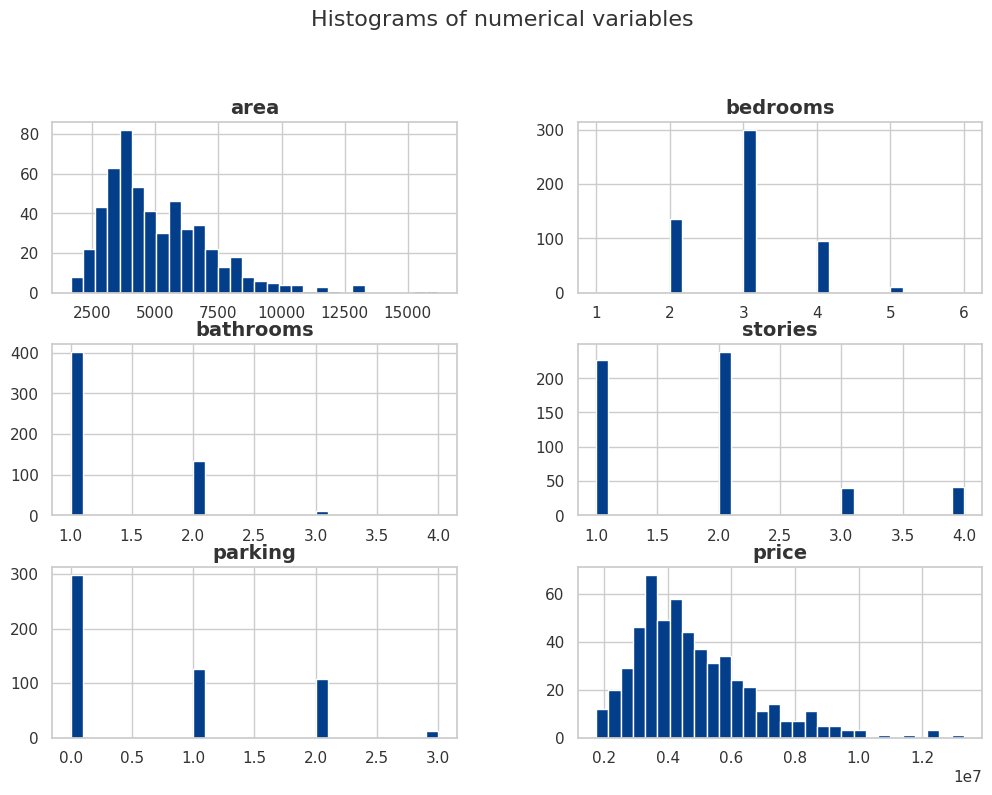

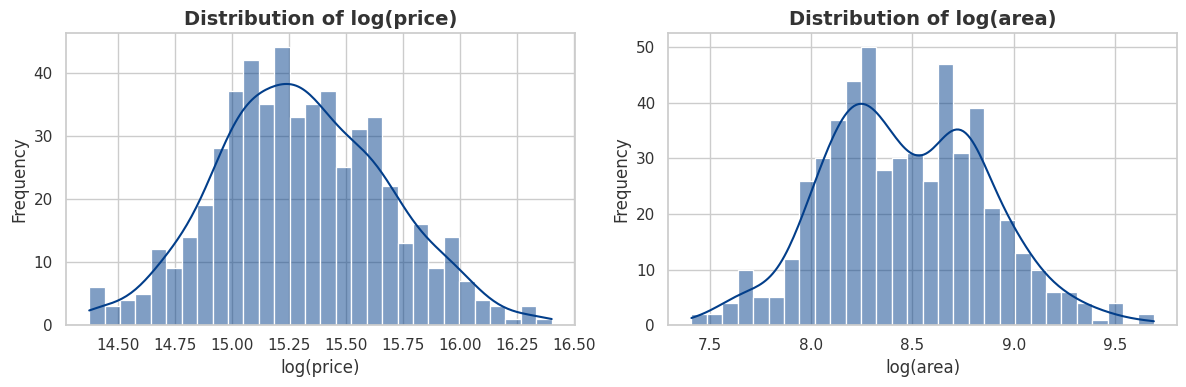

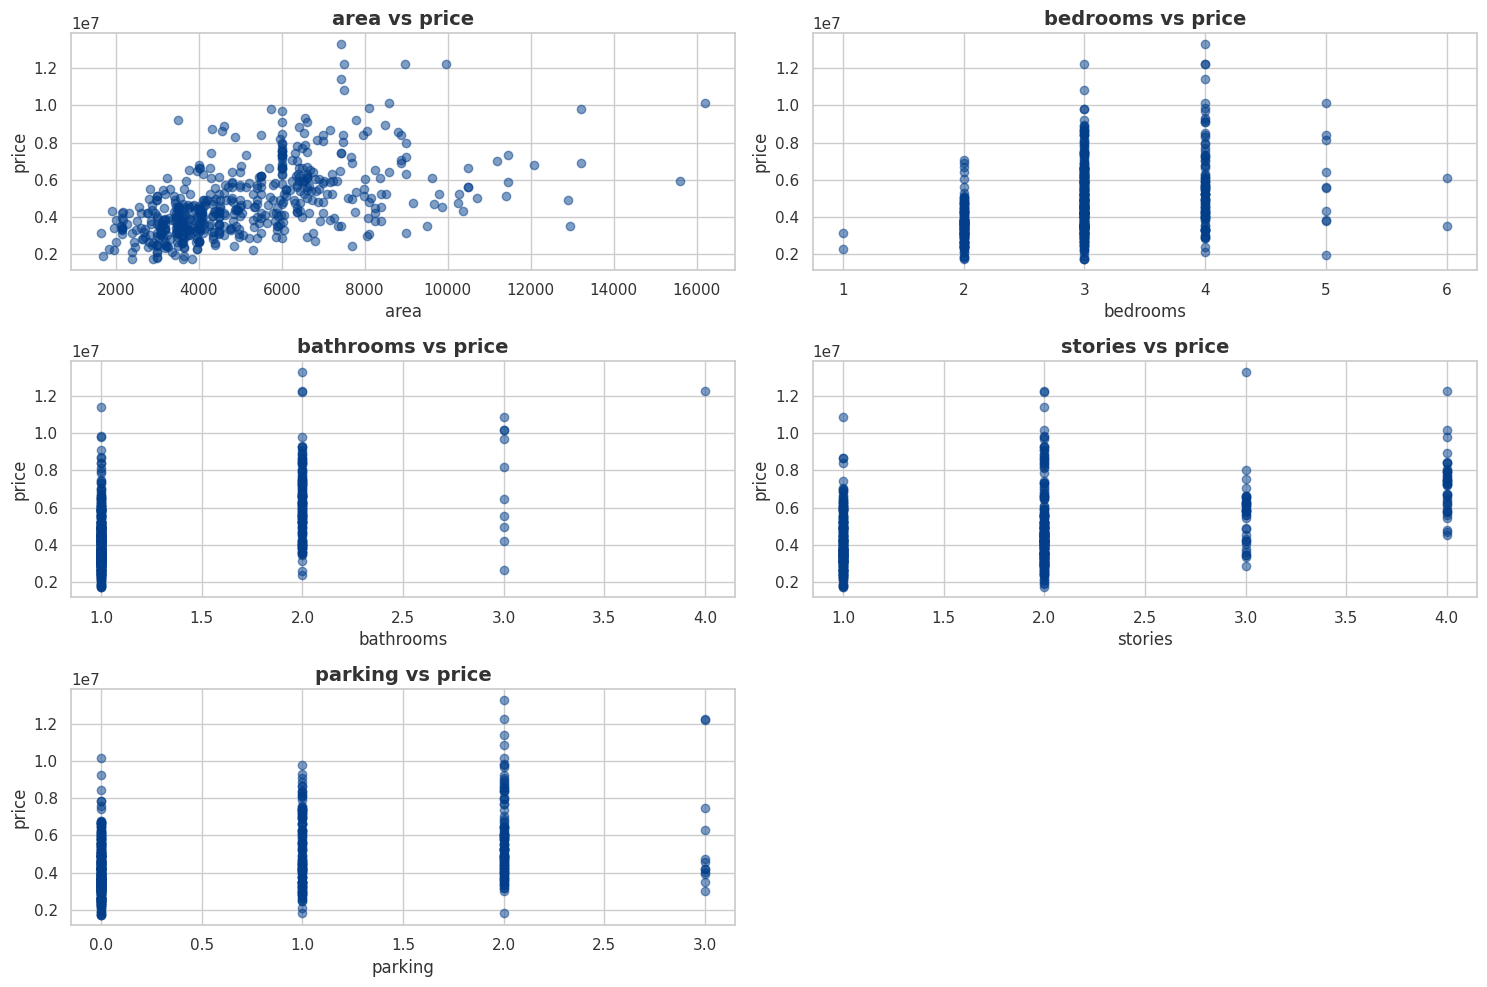

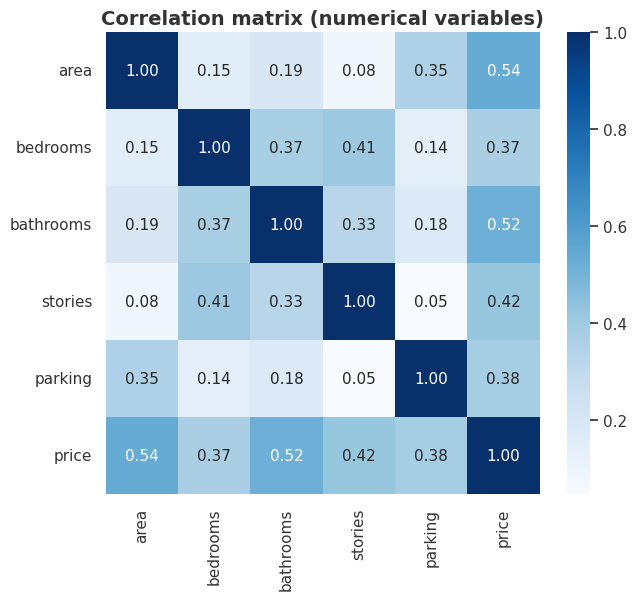

In [ ]:
# EDA cho biến numerical
# 1. Histogram for variables
df[num_cols + [target_col]].hist(figsize=(12,8), bins=30)
plt.suptitle("Histograms of numerical variables", y=1.02)
plt.show()

# 2 & 3. Log(price) and log(area) distribution -Combine into one row
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(np.log(df[target_col]), bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of log(price)")
axes[0].set_xlabel("log(price)")
axes[0].set_ylabel("Frequency")

sns.histplot(np.log(df['area']), bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution of log(area)")
axes[1].set_xlabel("log(area)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 4.Scatter some key variables with price - Adjust to 2 charts per row
plt.figure(figsize=(15, 10))

scatter_cols = ['area','bedrooms','bathrooms','stories','parking']
num_plots = len(scatter_cols)
num_rows = (num_plots + 1) // 2

for i, c in enumerate(scatter_cols):
    plt.subplot(num_rows, 2, i + 1)
    plt.scatter(df[c], df[target_col], alpha=0.5)
    plt.xlabel(c); plt.ylabel("price")
    plt.title(f"{c} vs price")

plt.tight_layout()
plt.show()

# 5. Correlation matrix between variables + price
numeric_for_corr = num_cols + [target_col]
plt.figure(figsize=(7,6))
sns.heatmap(df[numeric_for_corr].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation matrix (numerical variables)")
plt.show()

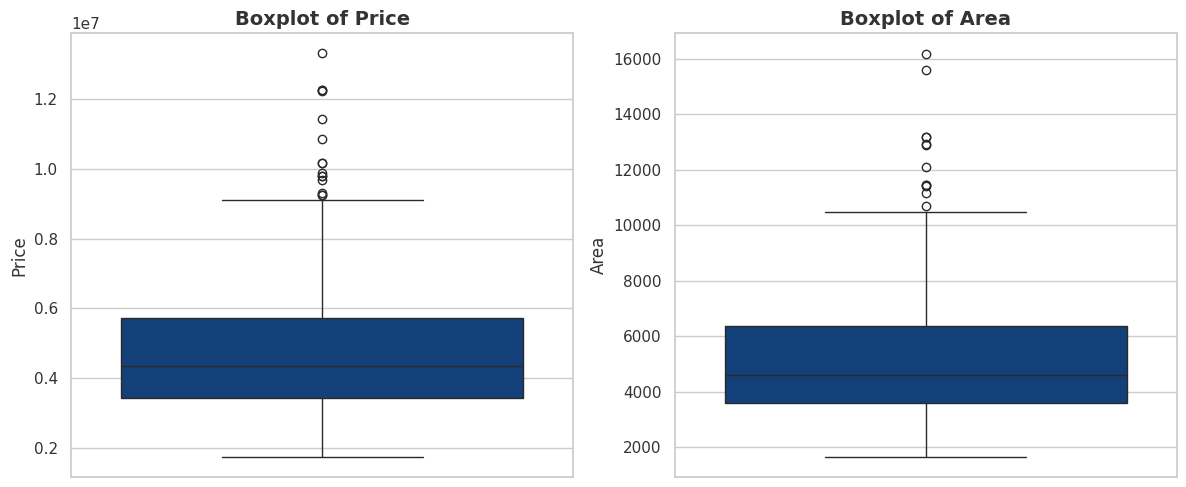

In [ ]:
# Created boxplots for price and area to visualise extreme observations.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['price'], ax=axes[0])
axes[0].set_title("Boxplot of Price")
axes[0].set_ylabel("Price")

sns.boxplot(y=df['area'], ax=axes[1])
axes[1].set_title("Boxplot of Area")
axes[1].set_ylabel("Area")

plt.tight_layout()
plt.show()

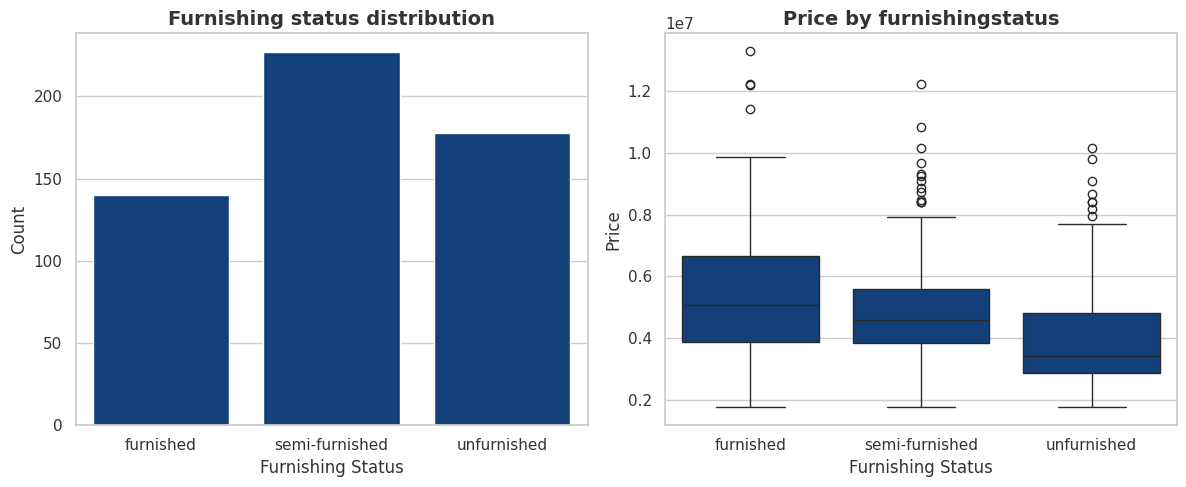

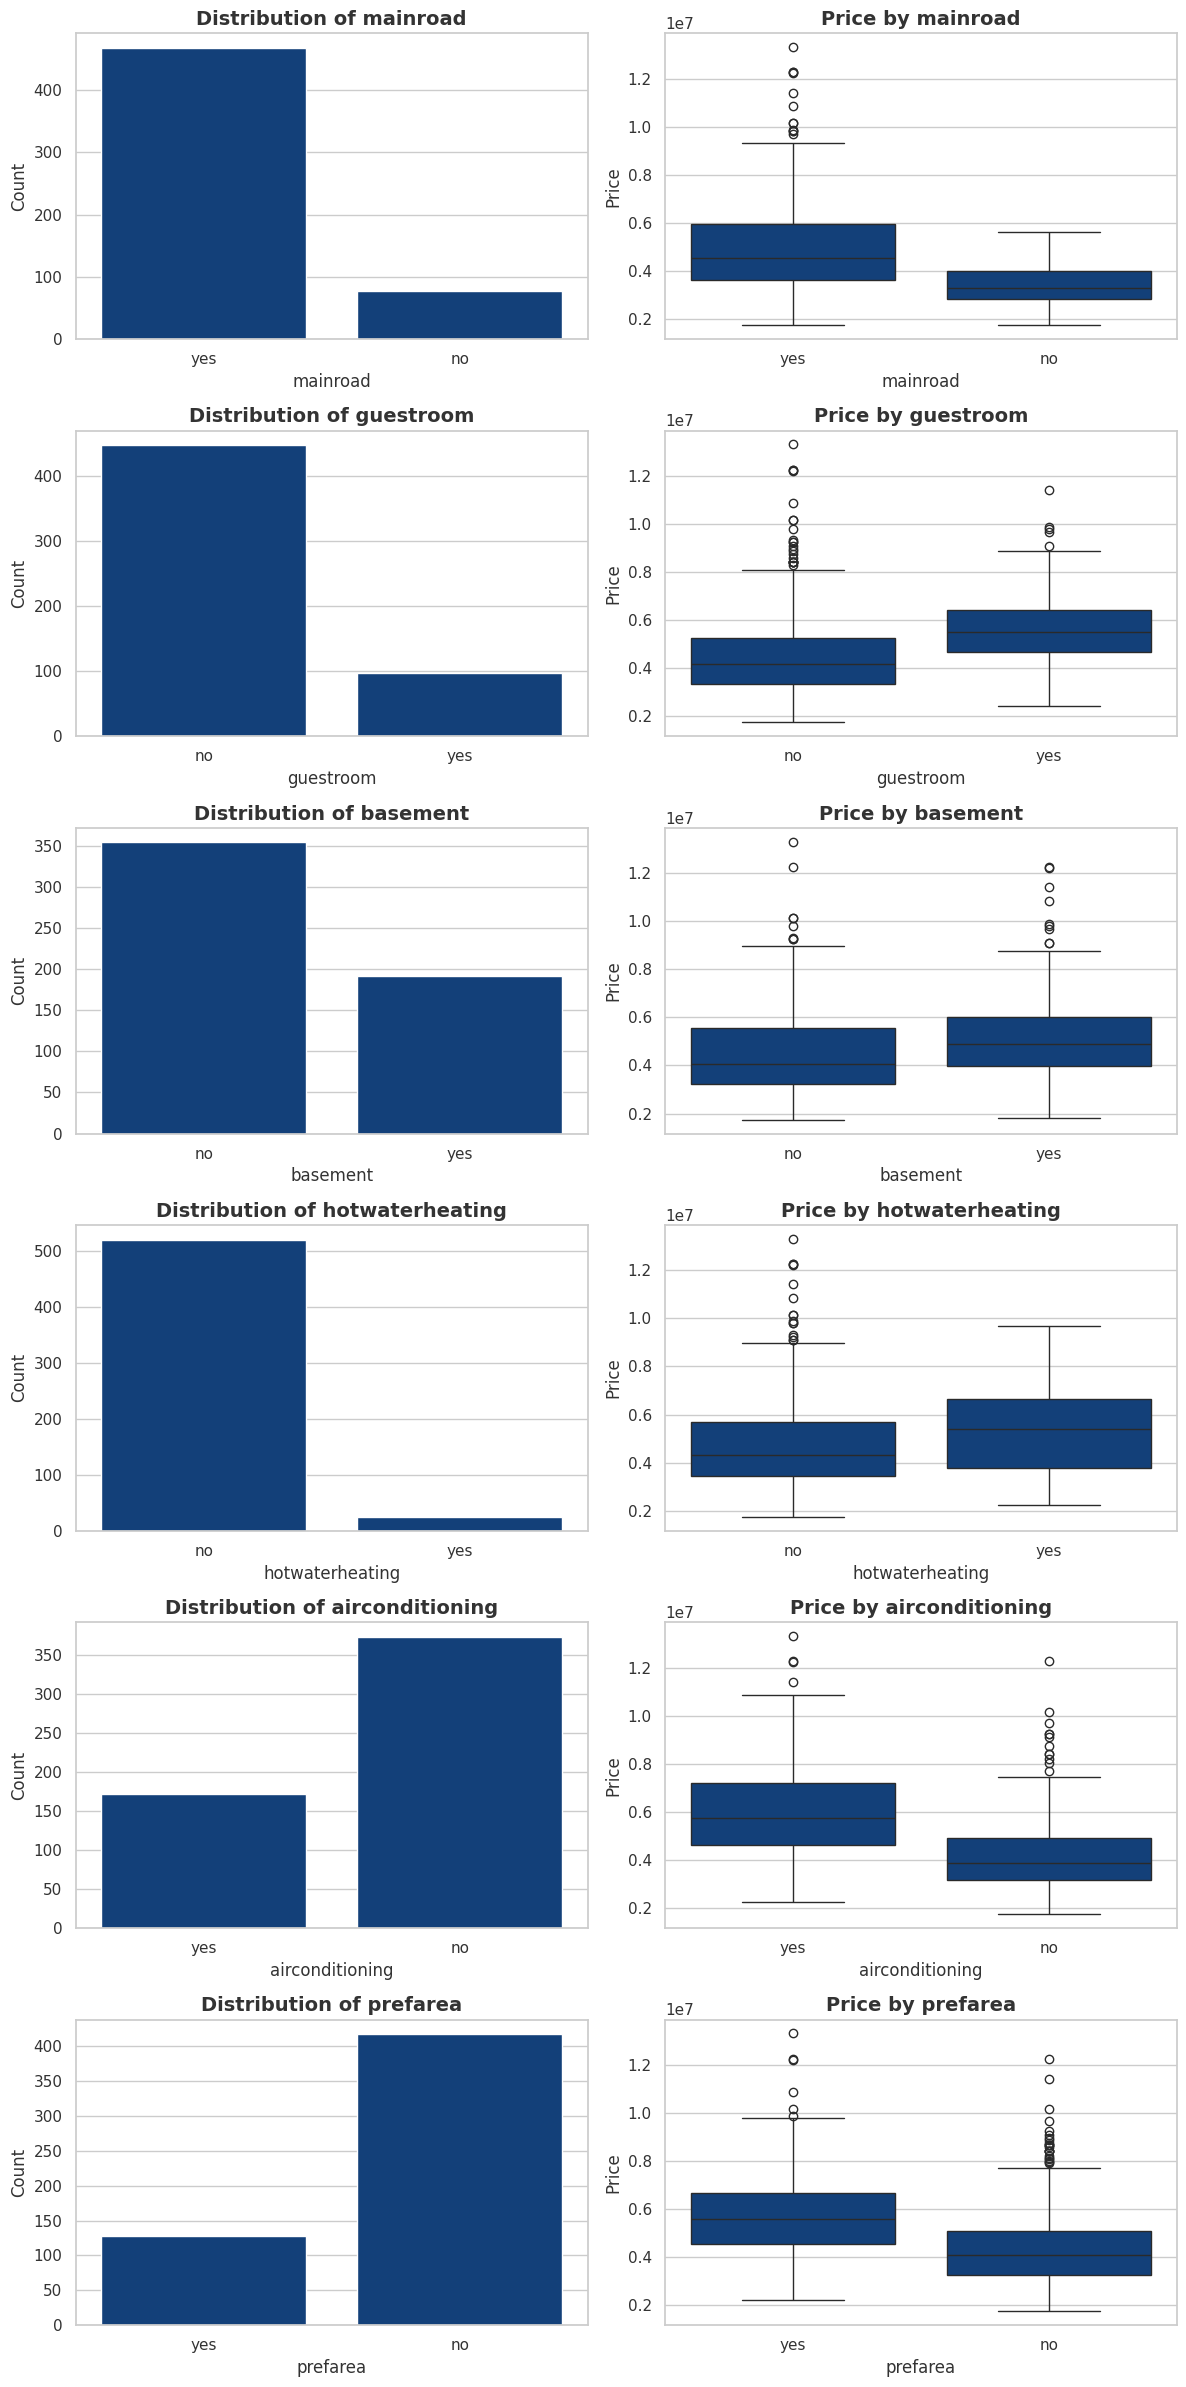

In [ ]:
# EFA for categorical variables (binary and multi-level)

# 1. 'furnishingstatus'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='furnishingstatus', data=df, ax=axes[0])
axes[0].set_title("Furnishing status distribution")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Furnishing Status")

sns.boxplot(x='furnishingstatus', y=target_col, data=df, ax=axes[1])
axes[1].set_title("Price by furnishingstatus")
axes[1].set_ylabel("Price")
axes[1].set_xlabel("Furnishing Status")

plt.tight_layout()
plt.show()

# 2. Yes/no variables (binary)
# Create a larger figure to contain all countplot and boxplot pairs
fig, axes = plt.subplots(len(yes_no_cols), 2, figsize=(12, 4 * len(yes_no_cols)))

for i, c in enumerate(yes_no_cols):
    #Countplot for binary variables
    sns.countplot(x=c, data=df, ax=axes[i,0])
    axes[i,0].set_title(f"Distribution of {c}")
    axes[i,0].set_ylabel("Count")
    axes[i,0].set_xlabel(c)

    # Boxplot of price by binary variable
    sns.boxplot(x=c, y=target_col, data=df, ax=axes[i,1])
    axes[i,1].set_title(f"Price by {c}")
    axes[i,1].set_ylabel("Price")
    axes[i,1].set_xlabel(c)

plt.tight_layout()
plt.show()

4.Handle outliers + check data after clean

Shape after cleaning: (545, 15)
              price   price_log          area    log_area
count  5.450000e+02  545.000000    545.000000  545.000000
mean   4.766729e+06   15.306070   5150.541284    8.466200
std    1.870440e+06    0.367149   2170.141023    0.393128
min    1.750000e+06   14.441620   1650.000000    7.586724
25%    3.430000e+06   15.048071   3600.000000    8.188689
50%    4.340000e+06   15.283385   4600.000000    8.433812
75%    5.740000e+06   15.562970   6360.000000    8.757784
max    1.330000e+07   16.170331  16200.000000    9.436449


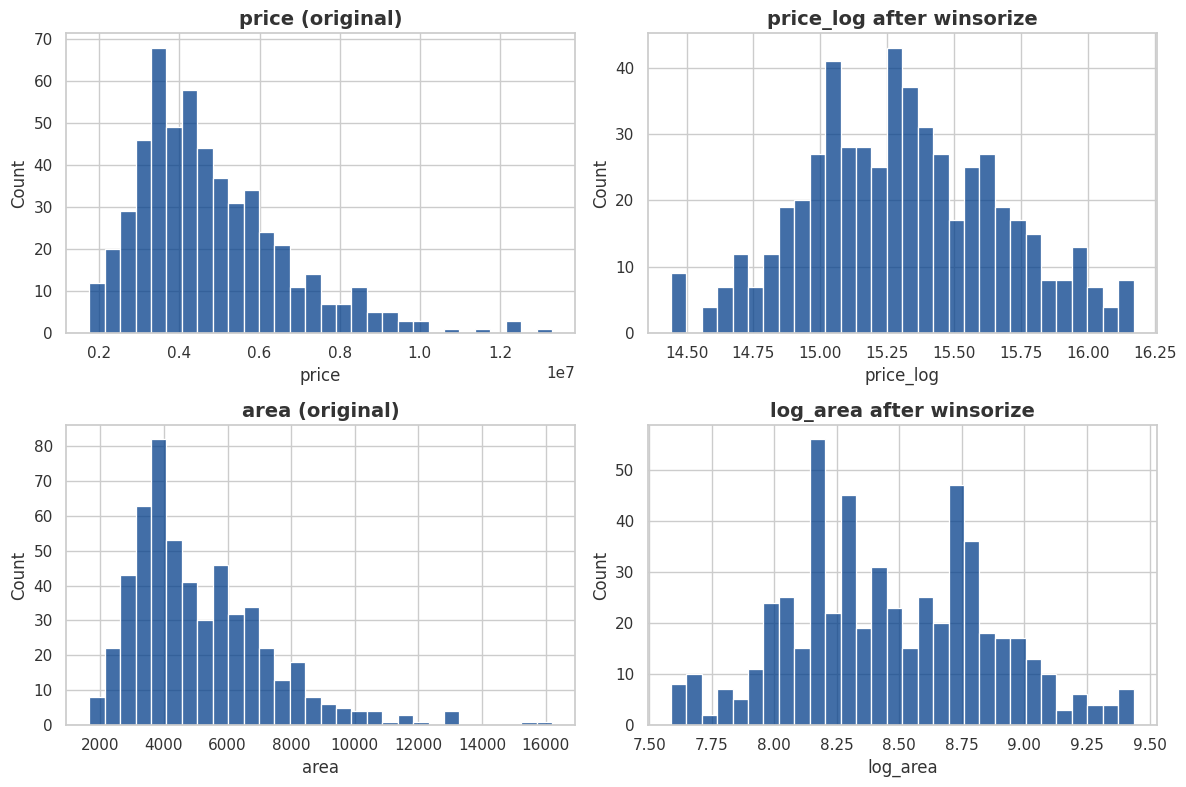

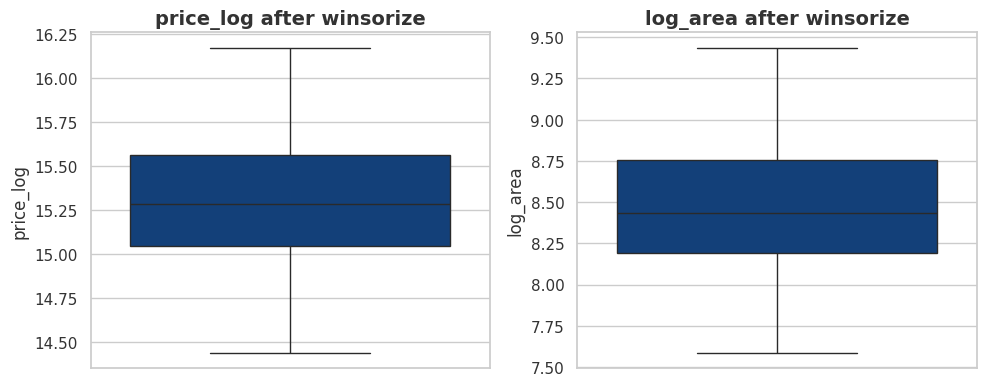

In [ ]:
# 4.1Create log variables for price and area
df['price_log'] = np.log(df['price'])
df['log_area']  = np.log(df['area'])

# 4.2 Winsorize function for 2 distribution ends (e.g. 1% and 99%)
def winsorize_series(s, lower_q=0.01, upper_q=0.99):

    lower = s.quantile(lower_q)
    upper = s.quantile(upper_q)
    return s.clip(lower=lower, upper=upper)

# 4.3 Apply winsorize to price_log and log_area
df['price_log'] = winsorize_series(df['price_log'], lower_q=0.01, upper_q=0.99)
df['log_area']  = winsorize_series(df['log_area'],  lower_q=0.01, upper_q=0.99)
df_clean = df.copy()

# 4.4 Quick check after clean
print("Shape after cleaning:", df_clean.shape)
print(df_clean[['price','price_log','area','log_area']].describe())

# 4.5 Some test plots (can be omitted if you want a compact notebook)
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.histplot(df_clean['price'], bins=30, ax=axes[0,0])
axes[0,0].set_title("price (original)")

sns.histplot(df_clean['price_log'], bins=30, ax=axes[0,1])
axes[0,1].set_title("price_log after winsorize")

sns.histplot(df_clean['area'], bins=30, ax=axes[1,0])
axes[1,0].set_title("area (original)")

sns.histplot(df_clean['log_area'], bins=30, ax=axes[1,1])
axes[1,1].set_title("log_area after winsorize")

plt.tight_layout()
plt.show()

# Boxplot to see if the outlier has softened
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.boxplot(y=df_clean['price_log'], ax=axes[0])
axes[0].set_title("price_log after winsorize")
sns.boxplot(y=df_clean['log_area'], ax=axes[1])
axes[1].set_title("log_area after winsorize")
plt.tight_layout()
plt.show()


5. Create dataset modeling from data after winsorize (df_clean)

In [ ]:

# 5.1 Select numerical variables (log + winsor)
num_vars = ['price_log', 'log_area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# 5.2 Select text yes/no variables
yes_no_cols = ['mainroad', 'guestroom', 'basement',
'hotwaterheating', 'airconditioning', 'prefarea']

# 5.3 Furnishingtatus variable has 3 levels
cat_vars = ['furnishingstatus']
# 5.4 Encode yes/no → 0/1
df_enc = df_clean.copy()
for c in yes_no_cols:
df_enc[c] = df_enc[c].map({'yes': 1, 'no': 0}).astype(int)

#5.5 One-hot encoding specifically for furnishingstatus (k-1 dummy)
df_model = pd.get_dummies(
df_enc[num_vars + yes_no_cols + cat_vars],
columns=cat_vars,
drop_first=True # drop one baseline level to avoid multicollinearity
)

#5.6 Confirm X, y for modeling
y_all = df_model['price_log'] #target
X_all = df_model.drop(columns=['price_log']) # features

print("df_model shape:", df_model.shape)
print("X_all shape :", X_all.shape)
print("y_all shape :", y_all.shape)

df_model.head()

df_model shape: (545, 14)
X_all shape : (545, 13)
y_all shape : (545,)


,price_log,log_area,bedrooms,bathrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,16.170331,8.911934,4,2,3,2,1,0,0,0,1,1,False,False
1,16.170331,9.100526,4,4,4,3,1,0,0,0,1,0,False,False
2,16.170331,9.206332,3,2,2,2,1,0,1,0,0,1,True,False
3,16.170331,8.922658,4,2,2,3,1,0,1,0,1,1,False,False
4,16.170331,8.911934,4,1,2,2,1,1,1,0,1,0,False,False


6. Split Train / Validation / Test + Standard Scaling

In [ ]:
# 6.1 train/val/test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42
)
print("Train:", X_train.shape)
print("Val:",   X_val.shape)
print("Test:",  X_test.shape)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 6.2. CALCULATE VIF (variance inflation factor) ON TRAIN SET (AFTER ENCODING, BEFORE SCALING)
# Make sure X_train is still a DataFrame, not an array
print("Type of X_train:", type(X_train))
print("X_train shape for VIF:", X_train.shape)

# If X_train is a numpy array, convert it back to a DataFrame using X_all.columns
if not isinstance(X_train, pd.DataFrame):
    X_train_vif = pd.DataFrame(X_train, columns=X_all.columns)
else:
    X_train_vif = X_train.copy()

display(X_train_vif.head())

# 6.2.1 Keep only numeric columns
X_vif_df = X_train_vif.select_dtypes(include=[np.number]).copy()
print("Numeric columns used for VIF:", X_vif_df.columns.tolist())

#6.2.2 Handling NaN / inf if present
X_vif_df = X_vif_df.replace([np.inf, -np.inf], np.nan).dropna()
print("Shape after dropping NaN/inf (for VIF):", X_vif_df.shape)

# 6.2.3 ADD constant
X_vif_const = sm.add_constant(X_vif_df)

# 6.2.4 Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

display(vif_data)
# 6.3 scaling for numeric
scaler = StandardScaler()

Xtr_s  = scaler.fit_transform(X_train)
Xval_s = scaler.transform(X_val)
Xte_s  = scaler.transform(X_test)


Train: (348, 13)
Val: (88, 13)
Test: (109, 13)
Type of X_train: <class 'pandas.core.frame.DataFrame'>
X_train shape for VIF: (348, 13)


,log_area,bedrooms,bathrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
159,8.055158,3,2,1,0,1,1,1,0,1,0,False,False
475,8.006368,2,1,2,0,1,0,0,0,0,0,True,False
527,7.586724,2,1,1,0,0,0,1,0,0,0,True,False
311,8.709465,2,1,1,1,1,0,1,0,0,0,True,False
479,8.205218,4,1,2,0,0,0,0,0,0,0,False,True


Numeric columns used for VIF: ['log_area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
Shape after dropping NaN/inf (for VIF): (348, 11)


,feature,VIF
0,const,597.641967
1,log_area,1.364474
2,bedrooms,1.357998
3,bathrooms,1.346346
4,stories,1.552808
5,parking,1.190602
6,mainroad,1.193933
7,guestroom,1.257951
8,basement,1.351131
9,hotwaterheating,1.045987


7. Generate a detailed regression report function (to produce the same output format for all the different regression techniques below)

In [ ]:
def detailed_regression_report(model,
                               X_train, y_train_log,
                               X_test,  y_test_log,
                               name="Regression model",
                               feature_names=None):

    # 1. Predict trên TRAIN, TEST (log)
    y_train_pred_log = model.predict(X_train).ravel()
    y_test_pred_log  = model.predict(X_test).ravel()

    # 2. Return to the ORIGINAL PRICE scale
    y_train_true = np.exp(y_train_log.values)
    y_test_true  = np.exp(y_test_log.values)
    y_train_pred = np.exp(y_train_pred_log)
    y_test_pred  = np.exp(y_test_pred_log)

    # 3. Residuals
    train_resid = y_train_true - y_train_pred

    # 4. Metrics TRAIN / TEST
    r2_tr  = r2_score(y_train_true, y_train_pred)
    mse_tr = mean_squared_error(y_train_true, y_train_pred)
    rmse_tr = np.sqrt(mse_tr)
    rss_tr = np.sum((y_train_true - y_train_pred)**2)

    r2_te  = r2_score(y_test_true, y_test_pred)
    mse_te = mean_squared_error(y_test_true, y_test_pred)
    rmse_te = np.sqrt(mse_te)
    rss_te = np.sum((y_test_true - y_test_pred)**2)

    print(f"\n<<<---------------- {name} ---------------->>>")

    # 5. Plot residual & Actual vs Predicted chart
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    sns.histplot(train_resid, kde=True, ax=axes[0])
    axes[0].set_title("Error Terms (Train residuals)")
    axes[0].set_xlabel("Errors")

    axes[1].scatter(y_test_true, y_test_pred, alpha=0.5)
    lims = [min(y_test_true.min(), y_test_pred.min()),
            max(y_test_true.max(), y_test_pred.max())]
    axes[1].plot(lims, lims, 'r--')
    axes[1].set_title("Test vs Prediction")
    axes[1].set_xlabel("Actual (Test)")
    axes[1].set_ylabel("Predicted")

    plt.tight_layout()
    plt.show()

    # 6.Subsidiary OLS estimate to get coef + p-value
    if isinstance(X_train, pd.DataFrame):
        X_train_sm = X_train.copy()
    else:
        n_features = X_train.shape[1]
        if feature_names is not None and len(feature_names) == n_features:
            col_names = list(feature_names)
        else:
            col_names = [f"x{i+1}" for i in range(n_features)]
        X_train_sm = pd.DataFrame(X_train, columns=col_names)

    X_train_const = sm.add_constant(X_train_sm)
    ols_sm = sm.OLS(y_train_log.values, X_train_const)
    ols_res = ols_sm.fit()

    coef_df = pd.DataFrame({
        "variable": ols_res.params.index,
        "coef":     ols_res.params.values,
        "std_err":  ols_res.bse.values,
        "t_value":  ols_res.tvalues.values,
        "p_value":  ols_res.pvalues.values
    })

    print("\n=== Coefficient & p-value table (auxiliary OLS on TRAIN) ===")
    display(coef_df)

    # 7. Return metrics (if you want to use them for comparison later)
    metrics_dict = {
        "R2_train":   r2_tr,
        "RMSE_train": rmse_tr,
        "MSE_train":  mse_tr,
        "RSS_train":  rss_tr,
        "R2_test":    r2_te,
        "RMSE_test":  rmse_te,
        "MSE_test":   mse_te,
        "RSS_test":   rss_te,
    }

    return metrics_dict, coef_df


8. MODEL 1: OLS (Linear Regression)

=== OLS Linear Regression ===
Train (RMSE, MAE, MAPE, R2): (np.float64(930811.3488632604), 657666.0756269365, np.float64(14.459295455149052), 0.7070835703100189)
Val   (RMSE, MAE, MAPE, R2): (np.float64(982570.7641125204), 738291.9101818799, np.float64(15.288037558535471), 0.659516319590636)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1200599.908178361), 931822.1965935704, np.float64(20.027020495865635), 0.6790945788744361)

=== OLS Metrics Table (Train – Val – Test) ===


,Split,RMSE,MAE,MAPE,R2
0,Train,9.308113e+05,657666.075627,14.459295,0.707084
1,Val,9.825708e+05,738291.910182,15.288038,0.659516
2,Test,1.200600e+06,931822.196594,20.027020,0.679095



<<<---------------- OLS Linear Regression ---------------->>>


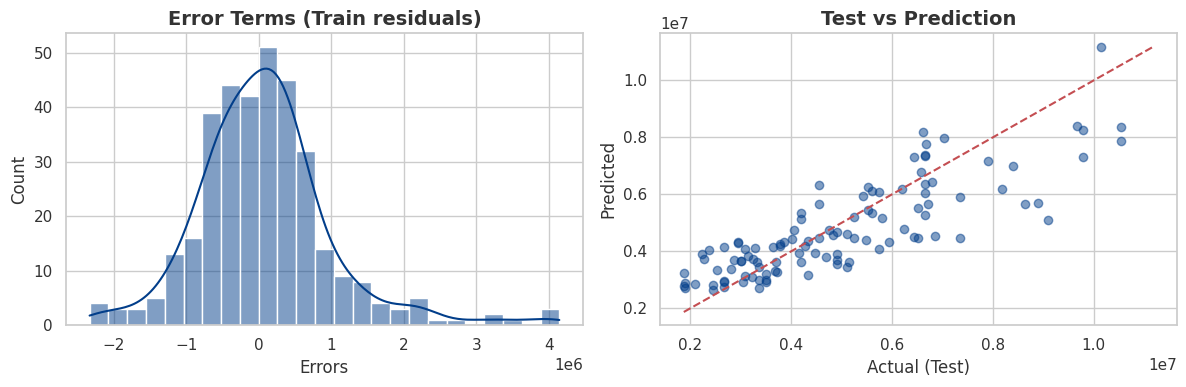


=== Coefficient & p-value table (auxiliary OLS on TRAIN) ===


,variable,coef,std_err,t_value,p_value
0,const,15.290087,0.010166,1503.989066,0.000000e+00
1,log_area,0.117058,0.011883,9.850834,2.887954e-20
2,bedrooms,0.018546,0.011856,1.564195,1.187187e-01
3,bathrooms,0.081411,0.011812,6.892185,2.748691e-11
4,stories,0.079486,0.012715,6.251201,1.242992e-09
5,parking,0.026332,0.011163,2.358760,1.891157e-02
6,mainroad,0.037783,0.011164,3.384226,7.987207e-04
7,guestroom,0.006106,0.011416,0.534865,5.930988e-01
8,basement,0.055189,0.011961,4.613931,5.639743e-06
9,hotwaterheating,0.033385,0.010424,3.202616,1.492916e-03


,variable,coef,std_err,t_value,p_value
0,const,15.290087,0.010166,1503.989066,0.000000e+00
1,log_area,0.117058,0.011883,9.850834,2.887954e-20
2,bedrooms,0.018546,0.011856,1.564195,1.187187e-01
3,bathrooms,0.081411,0.011812,6.892185,2.748691e-11
4,stories,0.079486,0.012715,6.251201,1.242992e-09
5,parking,0.026332,0.011163,2.358760,1.891157e-02
6,mainroad,0.037783,0.011164,3.384226,7.987207e-04
7,guestroom,0.006106,0.011416,0.534865,5.930988e-01
8,basement,0.055189,0.011961,4.613931,5.639743e-06
9,hotwaterheating,0.033385,0.010424,3.202616,1.492916e-03


In [ ]:
# === OLS LINEAR REGRESSION ===

# 1. eval_log_model function: evaluates RMSE, MAE, MAPE, R2 on the ORIGINAL PRICE SCALE
def eval_log_model(model, Xmat, y_true_log):
    y_pred_log = model.predict(Xmat).ravel()
    y_pred_log = np.clip(y_pred_log, -20, 20)

    # If it is log(price) then change to np.exp()
    y_true = np.exp(y_true_log.values)
    y_pred = np.exp(y_pred_log)

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-9, None))) * 100
    r2   = r2_score(y_true, y_pred)

    return rmse, mae, mape, r2

# 2. Actual vs Predicted drawing function
def plot_pred_vs_actual(y_true, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(5,4))
    plt.scatter(y_true, y_pred, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 3. Build OLS model
ols = LinearRegression()

# 4. Train on scaled TRAIN set
ols.fit(Xtr_s, y_train)

# 5. Evaluate (RMSE, MAE, MAPE, R2) cho TRAIN / VAL / TEST
ols_train = eval_log_model(ols, Xtr_s,  y_train)
ols_val   = eval_log_model(ols, Xval_s, y_val)
ols_test  = eval_log_model(ols, Xte_s,  y_test)

print("=== OLS Linear Regression ===")
print("Train (RMSE, MAE, MAPE, R2):", ols_train)
print("Val   (RMSE, MAE, MAPE, R2):", ols_val)
print("Test  (RMSE, MAE, MAPE, R2):", ols_test)

# 5b. METRICS SUMMARY TABLE FOR 3 SEQUENCES (Train – Val – Test)
ols_metrics_table = pd.DataFrame({
    "Split": ["Train", "Val", "Test"],
    "RMSE":  [ols_train[0], ols_val[0],  ols_test[0]],
    "MAE":   [ols_train[1], ols_val[1],  ols_test[1]],
    "MAPE":  [ols_train[2], ols_val[2],  ols_test[2]],
    "R2":    [ols_train[3], ols_val[3],  ols_test[3]],
})

print("\n=== OLS Metrics Table (Train – Val – Test) ===")
display(ols_metrics_table)

# 6. Detailed report + coef/p-value table with FULL VARIABLE NAMES
feature_names = X_all.columns

ols_metrics, ols_coef_df = detailed_regression_report(
    ols,
    Xtr_s,  y_train,   # TRAIN – log(price)
    Xte_s,  y_test,    # TEST  – log(price)
    name="OLS Linear Regression",
    feature_names=feature_names
)

display(ols_coef_df)


9.MODEL 2: Lasso Regression

=== Lasso Regression (baseline, alpha=0.0005) ===
Train (RMSE, MAE, MAPE, R2): (np.float64(930881.972960044), 657462.7832752109, np.float64(14.456616988709502), 0.7070391193198087)
Val   (RMSE, MAE, MAPE, R2): (np.float64(982713.7111450018), 737598.1452534293, np.float64(15.260963733922289), 0.6594172434245131)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1201690.7733759882), 932334.2394886394, np.float64(20.038538571667104), 0.678511164553653)
=== Lasso Regression – BASELINE (alpha = 0.0005) ===


,Split,RMSE,MAE,MAPE,R2
0,Train,9.308820e+05,657462.783275,14.456617,0.707039
1,Val,9.827137e+05,737598.145253,15.260964,0.659417
2,Test,1.201691e+06,932334.239489,20.038539,0.678511


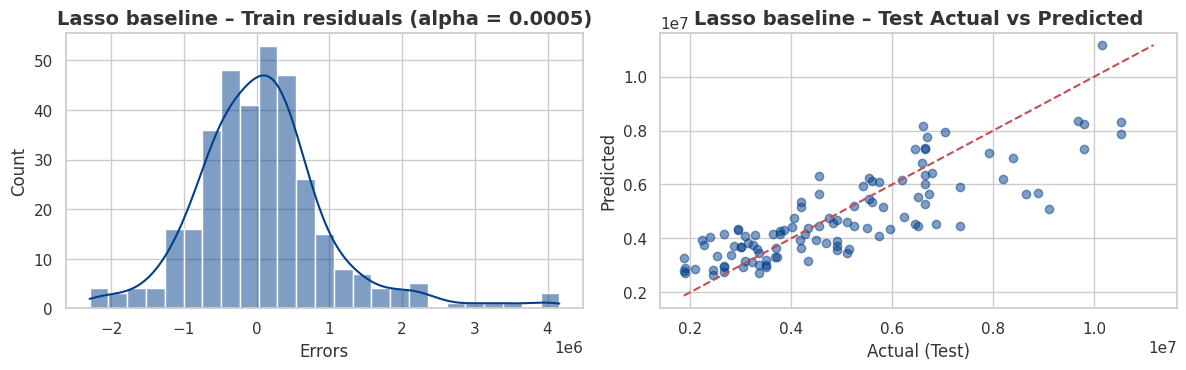


=== Lasso BASELINE coefficients (sklearn Lasso, no p-values) ===


,variable,coef_lasso
0,log_area,0.116922
1,bedrooms,0.018351
2,bathrooms,0.081293
3,stories,0.079280
4,parking,0.026131
5,mainroad,0.037617
6,guestroom,0.005884
7,basement,0.054918
8,hotwaterheating,0.032920
9,airconditioning,0.061737


In [ ]:
# === LASSO REGRESSION – BASELINE (alpha = 0.0005) ===

from sklearn.linear_model import Lasso

# 0. Get the original variable name (after one-hot)
feature_names = X_all.columns

# 1. Build Lasso baseline
lasso_base = Lasso(
    alpha=0.0005,
    random_state=42,
    max_iter=10000
)

# 2. Train
lasso_base.fit(Xtr_s, y_train)

# 3. Evaluate on TRAIN / VAL / TEST
lasso_base_train = eval_log_model(lasso_base, Xtr_s,  y_train)
lasso_base_val   = eval_log_model(lasso_base, Xval_s, y_val)
lasso_base_test  = eval_log_model(lasso_base, Xte_s,  y_test)

print("=== Lasso Regression (baseline, alpha=0.0005) ===")
print("Train (RMSE, MAE, MAPE, R2):", lasso_base_train)
print("Val   (RMSE, MAE, MAPE, R2):", lasso_base_val)
print("Test  (RMSE, MAE, MAPE, R2):", lasso_base_test)

print("=== Lasso Regression – BASELINE (alpha = 0.0005) ===")
metrics_lasso_base = pd.DataFrame(
    [
        ["Train", *lasso_base_train],
        ["Val",   *lasso_base_val],
        ["Test",  *lasso_base_test],
    ],
    columns=["Split", "RMSE", "MAE", "MAPE", "R2"]
)
display(metrics_lasso_base)

# 4. Residuals + Actual vs Predicted

# 4.1 Residuals on TRAIN (original price scale)
y_train_true = np.exp(y_train.values)
y_train_pred = np.exp(lasso_base.predict(Xtr_s).ravel())
train_resid  = y_train_true - y_train_pred

# 4.2 Actual vs Predicted on TEST
y_test_true  = np.exp(y_test.values)
y_pred_lasso = np.exp(lasso_base.predict(Xte_s).ravel())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_resid, kde=True, ax=axes[0])
axes[0].set_title("Lasso baseline – Train residuals (alpha = 0.0005)")
axes[0].set_xlabel("Errors")

lims = [min(y_test_true.min(), y_pred_lasso.min()),
        max(y_test_true.max(), y_pred_lasso.max())]
axes[1].scatter(y_test_true, y_pred_lasso, alpha=0.5)
axes[1].plot(lims, lims, "r--")
axes[1].set_title("Lasso baseline – Test Actual vs Predicted")
axes[1].set_xlabel("Actual (Test)")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# 5. LASSO COEFFICIENT TABLE WITH FULL VARIABLE NAMES
lasso_base_coef_df = pd.DataFrame({
    "variable":   feature_names,
    "coef_lasso": lasso_base.coef_.ravel()
})

print("\n=== Lasso BASELINE coefficients (sklearn Lasso, no p-values) ===")
display(lasso_base_coef_df)


9.2 Lasso hyperparameter tuning

=== Lasso hyperparameter search (validation-based) ===
alpha = 1e-05    -> Val RMSE = 982,573, Val R² = 0.660
alpha = 5e-05    -> Val RMSE = 982,582, Val R² = 0.660
alpha = 0.0001   -> Val RMSE = 982,593, Val R² = 0.660
alpha = 0.0005   -> Val RMSE = 982,714, Val R² = 0.659
alpha = 0.001    -> Val RMSE = 982,935, Val R² = 0.659
alpha = 0.005    -> Val RMSE = 985,088, Val R² = 0.658

Best alpha for Lasso: 1e-05

=== Final Lasso Regression (after tuning alpha) ===
Train (RMSE, MAE, MAPE, R2): (np.float64(930811.9953204425), 657661.8951416567, np.float64(14.459240639782688), 0.707083163443481)
Val   (RMSE, MAE, MAPE, R2): (np.float64(982572.8307164076), 738278.0225698504, np.float64(15.287494554761711), 0.6595148873362617)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1200621.0580305625), 931832.3700491565, np.float64(20.027248407184537), 0.6790832725900323)

=== Final Lasso Regression (after tuning alpha) ===


,Split,RMSE,MAE,MAPE,R2
0,Train,9.308120e+05,657661.895142,14.459241,0.707083
1,Val,9.825728e+05,738278.022570,15.287495,0.659515
2,Test,1.200621e+06,931832.370049,20.027248,0.679083


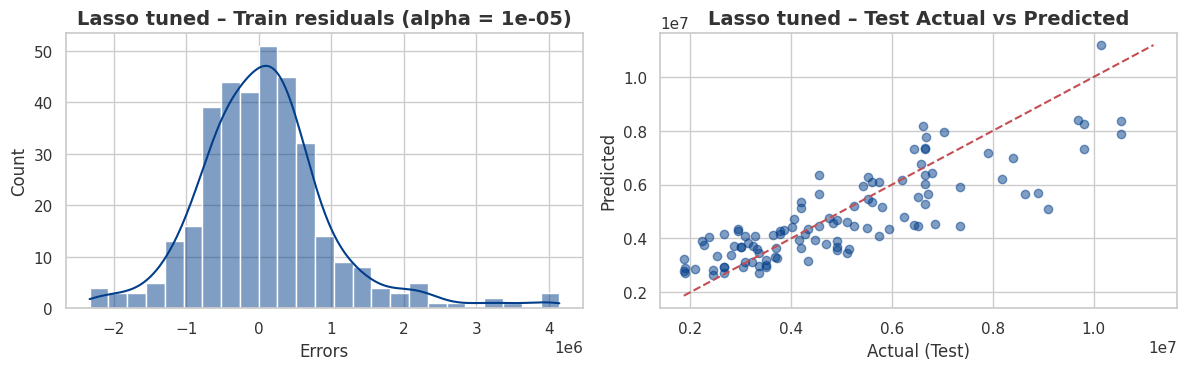


=== Lasso coefficients (alpha = 1e-05) – sklearn Lasso, no p-values ===


,variable,coef_lasso
0,log_area,0.117055
1,bedrooms,0.018542
2,bathrooms,0.081408
3,stories,0.079482
4,parking,0.026328
5,mainroad,0.037780
6,guestroom,0.006101
7,basement,0.055184
8,hotwaterheating,0.033376
9,airconditioning,0.061836


In [ ]:
# === LASSO REGRESSION – HYPERPARAMETER SEARCH (alpha) ===

from sklearn.linear_model import Lasso

# 0. Variable name (after one-hot)
feature_names = X_all.columns

# 1. List of alphas to try for Lasso
alpha_list = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3]

best_alpha    = None
best_val_rmse = np.inf
best_lasso    = None

print("=== Lasso hyperparameter search (validation-based) ===")
for a in alpha_list:
    m = Lasso(alpha=a, random_state=42, max_iter=10000)
    m.fit(Xtr_s, y_train)

    val_rmse, val_mae, val_mape, val_r2 = eval_log_model(m, Xval_s, y_val)
    print(f"alpha = {a:<8} -> Val RMSE = {val_rmse:,.0f}, Val R² = {val_r2:.3f}")

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_alpha    = a
        best_lasso    = m

print("\nBest alpha for Lasso:", best_alpha)

# 2. Use the best Lasso model
lasso = best_lasso

lasso_train = eval_log_model(lasso, Xtr_s,  y_train)
lasso_val   = eval_log_model(lasso, Xval_s, y_val)
lasso_test  = eval_log_model(lasso, Xte_s,  y_test)

print("\n=== Final Lasso Regression (after tuning alpha) ===")
print("Train (RMSE, MAE, MAPE, R2):", lasso_train)
print("Val   (RMSE, MAE, MAPE, R2):", lasso_val)
print("Test  (RMSE, MAE, MAPE, R2):", lasso_test)

print("\n=== Final Lasso Regression (after tuning alpha) ===")
metrics_lasso_tuned = pd.DataFrame(
    [
        ["Train", *lasso_train],
        ["Val",   *lasso_val],
        ["Test",  *lasso_test],
    ],
    columns=["Split", "RMSE", "MAE", "MAPE", "R2"]
)
display(metrics_lasso_tuned)

# 3. Residuals + Actual vs Predicted (using Lasso tuned)

# 3.1 Residuals TRAIN
y_train_true = np.exp(y_train.values)
y_train_pred = np.exp(lasso.predict(Xtr_s).ravel())
train_resid  = y_train_true - y_train_pred

# 3.2 Actual vs Predicted TEST
y_test_true  = np.exp(y_test.values)
y_pred_lasso = np.exp(lasso.predict(Xte_s).ravel())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_resid, kde=True, ax=axes[0])
axes[0].set_title(f"Lasso tuned – Train residuals (alpha = {best_alpha})")
axes[0].set_xlabel("Errors")

lims = [min(y_test_true.min(), y_pred_lasso.min()),
        max(y_test_true.max(), y_pred_lasso.max())]
axes[1].scatter(y_test_true, y_pred_lasso, alpha=0.5)
axes[1].plot(lims, lims, "r--")
axes[1].set_title("Lasso tuned – Test Actual vs Predicted")
axes[1].set_xlabel("Actual (Test)")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# 4. Lasso tuned coefficient table with full variable names
lasso_coef_df = pd.DataFrame({
    "variable":   feature_names,
    "coef_lasso": lasso.coef_.ravel()
})

print(f"\n=== Lasso coefficients (alpha = {best_alpha}) – sklearn Lasso, no p-values ===")
display(lasso_coef_df)


In [ ]:
Baseline vs tuning

=== Visualization Comparison of Lasso Baseline vs Lasso Tuned ===


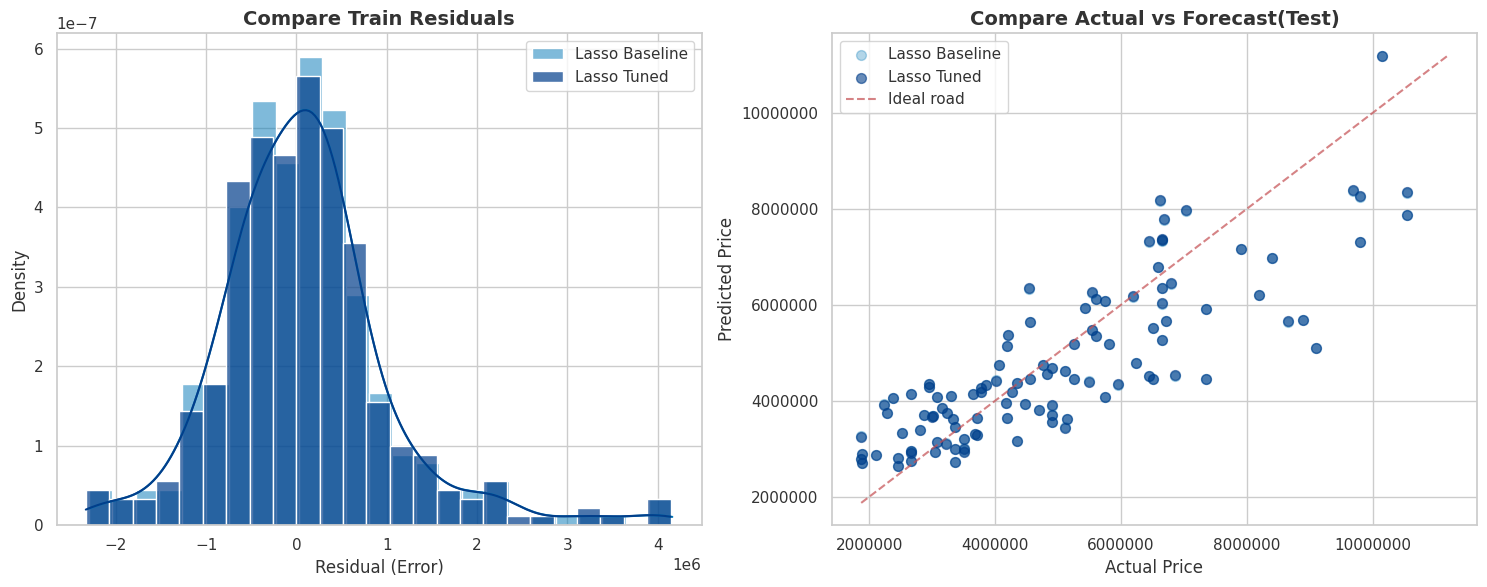

In [ ]:
print("=== Visualization Comparison of Lasso Baseline vs Lasso Tuned ===")

# --- 1. Get the data needed for Lasso Baseline ---
# y_train (price_log) -> y_train_true (original price)
y_train_true_base = np.exp(y_train.values)
y_test_true_base = np.exp(y_test.values)

# Predict on log scale
y_train_pred_log_base = lasso_base.predict(Xtr_s).ravel()
y_test_pred_log_base = lasso_base.predict(Xte_s).ravel()

# Convert to original price scale
y_train_pred_base = np.exp(y_train_pred_log_base)
y_test_pred_base = np.exp(y_test_pred_log_base)

# Calculate Residuals (Train)
train_resid_base = y_train_true_base - y_train_pred_base

# --- 2. Get the data needed for Lasso Tuned ---
# y_train (price_log) -> y_train_true (original price)
y_train_true_tuned = np.exp(y_train.values) # Same as base
y_test_true_tuned = np.exp(y_test.values) # Same as base

# Predict on log scale
y_train_pred_log_tuned = lasso.predict(Xtr_s).ravel()
y_test_pred_log_tuned = lasso.predict(Xte_s).ravel()

# Convert to original price scale
y_train_pred_tuned = np.exp(y_train_pred_log_tuned)
y_test_pred_tuned = np.exp(y_test_pred_log_tuned)

# Calculate Residuals (Train)
train_resid_tuned = y_train_true_tuned - y_train_pred_tuned

# --- 3. Draw a comparison chart ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Comparing Histograms of Train Residuals
sns.histplot(train_resid_base, kde=True, ax=axes[0], color='#0077B6', label='Lasso Baseline', alpha=0.5, stat='density')
sns.histplot(train_resid_tuned, kde=True, ax=axes[0], color='#023E8A', label='Lasso Tuned', alpha=0.7, stat='density')
axes[0].set_title('Compare Train Residuals')
axes[0].set_xlabel('Residual (Error)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Chart 2: Comparison of Scatter Plot Actual vs Predicted (Test)
axes[1].scatter(y_test_true_base, y_test_pred_base, alpha=0.3, color='#0077B6', label='Lasso Baseline', s=50)
axes[1].scatter(y_test_true_tuned, y_test_pred_tuned, alpha=0.6, color='#023E8A', label='Lasso Tuned', s=50)

# Draw the line y=x
min_val = min(y_test_true_base.min(), y_test_pred_base.min(), y_test_true_tuned.min(), y_test_pred_tuned.min())
max_val = max(y_test_true_base.max(), y_test_pred_base.max(), y_test_true_tuned.max(), y_test_pred_tuned.max())
lims = [min_val, max_val]
axes[1].plot(lims, lims, 'r--', alpha=0.7, label='Ideal road')

axes[1].set_title('Compare Actual vs Forecast(Test)')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].legend()
axes[1].ticklabel_format(style='plain', axis='x')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

**10**. Evaluation function common to all tree-based models

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBRegressor


def run_tree_experiment(exp_name, model,
                        Xtr=Xtr_s, Xval=Xval_s, Xte=Xte_s,
                        ytr=y_train, yval=y_val, yte=y_test):
    model.fit(Xtr, ytr)

    tr = eval_log_model(model, Xtr, ytr)
    va = eval_log_model(model, Xval, yval)
    te = eval_log_model(model, Xte, yte)

    print(f"\n=== {exp_name} ===")
    print("Train (RMSE, MAE, MAPE, R2):", tr)
    print("Val   (RMSE, MAE, MAPE, R2):", va)
    print("Test  (RMSE, MAE, MAPE, R2):", te)

    return model, tr, va, te

# Assume X_all is the full feature DataFrame (after one-hot, before scaling)
feature_names = X_all.columns

def plot_feature_importance(model, feature_names, top_n=15, title="Feature importance"):
    importances = getattr(model, "feature_importances_", None)
    if importances is None:
        print("⚠️ Model does not have feature_importances_ attribute.")
        return

    importances = np.array(importances)
    idx_sorted = np.argsort(importances)[::-1]
    idx_top = idx_sorted[:top_n]

    fi_df = pd.DataFrame({
        "feature": np.array(feature_names)[idx_top],
        "importance": importances[idx_top]
    })

    print("=== Top feature importances ===")
    display(fi_df)

    plt.figure(figsize=(8, max(4, top_n * 0.3)))
    sns.barplot(data=fi_df, x="importance", y="feature")
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


10.1 Models 3:Decision Tree

In [ ]:
# === DECISION TREE REGRESSOR – BASELINE ===

dt_results = []

dt_base = DecisionTreeRegressor(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

dt_base, dt_base_tr, dt_base_val, dt_base_te = run_tree_experiment(
    "DT_exp0_baseline", dt_base
)

dt_results.append(["DT_exp0_baseline",
                   *dt_base_tr, *dt_base_val, *dt_base_te])

cols_tree = ["Experiment",
             "RMSE_train","MAE_train","MAPE_train","R2_train",
             "RMSE_val","MAE_val","MAPE_val","R2_val",
             "RMSE_test","MAE_test","MAPE_test","R2_test"]

df_dt = pd.DataFrame(dt_results, columns=cols_tree)

print("\n>>> Decision Tree – Baseline only:")
display(df_dt)



=== DT_exp0_baseline ===
Train (RMSE, MAE, MAPE, R2): (np.float64(47868.88363364121), 4180.116579792286, np.float64(0.16613189921308183), 0.9992253117106122)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1382829.3689273673), 986952.1405075374, np.float64(20.705523103785087), 0.32561824147944485)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1550378.695952273), 1156170.341942103, np.float64(25.039401207074473), 0.4648740322689108)

>>> Decision Tree – Baseline only:


,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
0,DT_exp0_baseline,47868.883634,4180.11658,0.166132,0.999225,1.382829e+06,986952.140508,20.705523,0.325618,1.550379e+06,1.156170e+06,25.039401,0.464874


10.2. Decision tree regressor 3 Experiments

In [ ]:
# === DECISION TREE REGRESSOR – 3 EXPERIMENTS ===
# (continue using dt_results which already has baseline)

# EXP 1: Smaller depth to avoid overfitting
dt_exp1 = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
dt_exp1, dt1_tr, dt1_val, dt1_te = run_tree_experiment(
    "DT_exp1_depth5", dt_exp1
)
dt_results.append(["DT_exp1_depth5",
                   *dt1_tr, *dt1_val, *dt1_te])

# EXP 2: depth 7, leaf small
dt_exp2 = DecisionTreeRegressor(
    max_depth=7,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42
)
dt_exp2, dt2_tr, dt2_val, dt2_te = run_tree_experiment(
    "DT_exp2_depth7", dt_exp2
)
dt_results.append(["DT_exp2_depth7",
                   *dt2_tr, *dt2_val, *dt2_te])

# EXP 3: depth 4, leaf bigger
dt_exp3 = DecisionTreeRegressor(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)
dt_exp3, dt3_tr, dt3_val, dt3_te = run_tree_experiment(
    "DT_exp3_depth4_leaf4", dt_exp3
)
dt_results.append(["DT_exp3_depth4_leaf4",
                   *dt3_tr, *dt3_val, *dt3_te])

df_dt = pd.DataFrame(dt_results, columns=cols_tree)

print("\n>>> Decision Tree – Baseline + 3 experiments:")
display(df_dt.sort_values("R2_test", ascending=False))



=== DT_exp1_depth5 ===
Train (RMSE, MAE, MAPE, R2): (np.float64(871211.62919534), 632255.9311983039, np.float64(14.046111297878536), 0.7433934603680803)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1118285.855145606), 848623.3732313626, np.float64(17.8118984915984), 0.5589637482484209)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1608190.9379156441), 1196346.4613727704, np.float64(25.69548989376709), 0.4242212092182558)

=== DT_exp2_depth7 ===
Train (RMSE, MAE, MAPE, R2): (np.float64(653554.8067100545), 468068.1197595751, np.float64(10.584279449691367), 0.8555942725442782)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1266410.4420198912), 945141.6303735101, np.float64(20.257184589769768), 0.434389333758587)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1535647.4846036746), 1146396.5469416073, np.float64(24.596904213221123), 0.47499491770050173)

=== DT_exp3_depth4_leaf4 ===
Train (RMSE, MAE, MAPE, R2): (np.float64(1031993.5932687651), 766601.4170130793, np.float64(16.89038279611199), 0.6399403999498454

,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
2,DT_exp2_depth7,6.535548e+05,468068.119760,10.584279,0.855594,1.266410e+06,945141.630374,20.257185,0.434389,1.535647e+06,1.146397e+06,24.596904,0.474995
0,DT_exp0_baseline,4.786888e+04,4180.116580,0.166132,0.999225,1.382829e+06,986952.140508,20.705523,0.325618,1.550379e+06,1.156170e+06,25.039401,0.464874
1,DT_exp1_depth5,8.712116e+05,632255.931198,14.046111,0.743393,1.118286e+06,848623.373231,17.811898,0.558964,1.608191e+06,1.196346e+06,25.695490,0.424221
3,DT_exp3_depth4_leaf4,1.031994e+06,766601.417013,16.890383,0.639940,1.129358e+06,851352.024709,17.494547,0.550187,1.659034e+06,1.260339e+06,26.544173,0.387239


10.3. Decision Tree RandomizedSearchCV

In [ ]:
# === DECISION TREE REGRESSOR – RANDOMIZED SEARCH ===

dt_param_dist = {
    "max_depth":        [3, 4, 5, 6, 8, None],
    "min_samples_split":[2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features":     ["auto", "sqrt", 0.5, None]
}

dt_base_rs = DecisionTreeRegressor(random_state=42)

dt_rand = RandomizedSearchCV(
    estimator=dt_base_rs,
    param_distributions=dt_param_dist,
    n_iter=30,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

dt_rand.fit(Xtr_s, y_train)

print("\nBest params (Decision Tree):", dt_rand.best_params_)

dt_best = dt_rand.best_estimator_

dt_best_tr  = eval_log_model(dt_best, Xtr_s,  y_train)
dt_best_val = eval_log_model(dt_best, Xval_s, y_val)
dt_best_te  = eval_log_model(dt_best, Xte_s,  y_test)

exp_name = "DT_exp4_randomSearch"
dt_results = [row for row in dt_results if row[0] != exp_name]

dt_results.append([exp_name,
                   *dt_best_tr, *dt_best_val, *dt_best_te])

df_dt = pd.DataFrame(dt_results, columns=cols_tree)

print("\n>>> Decision Tree – All (baseline + 3 exp + randomSearch):")
display(df_dt.sort_values("R2_test", ascending=False))


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params (Decision Tree): {'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.5, 'max_depth': None}

>>> Decision Tree – All (baseline + 3 exp + randomSearch):


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
2,DT_exp2_depth7,6.535548e+05,468068.119760,10.584279,0.855594,1.266410e+06,945141.630374,20.257185,0.434389,1.535647e+06,1.146397e+06,24.596904,0.474995
4,DT_exp4_randomSearch,9.316133e+05,658994.621035,14.332816,0.706579,1.175043e+06,880812.031270,18.065345,0.513059,1.545399e+06,1.222091e+06,26.968549,0.468306
0,DT_exp0_baseline,4.786888e+04,4180.116580,0.166132,0.999225,1.382829e+06,986952.140508,20.705523,0.325618,1.550379e+06,1.156170e+06,25.039401,0.464874
1,DT_exp1_depth5,8.712116e+05,632255.931198,14.046111,0.743393,1.118286e+06,848623.373231,17.811898,0.558964,1.608191e+06,1.196346e+06,25.695490,0.424221
3,DT_exp3_depth4_leaf4,1.031994e+06,766601.417013,16.890383,0.639940,1.129358e+06,851352.024709,17.494547,0.550187,1.659034e+06,1.260339e+06,26.544173,0.387239


10.4. Select best Decision Tree + Feature importance

>>> Best Decision Tree experiment based on Test R²:


,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
2,DT_exp2_depth7,653554.80671,468068.11976,10.584279,0.855594,1266410.44202,945141.630374,20.257185,0.434389,1535647.484604,1146396.546942,24.596904,0.474995


=== Top feature importances ===


,feature,importance
0,log_area,0.511730
1,bathrooms,0.119728
2,furnishingstatus_unfurnished,0.107442
3,airconditioning,0.054309
4,basement,0.048662
5,stories,0.037133
6,bedrooms,0.027149
7,mainroad,0.025288
8,prefarea,0.022464
9,hotwaterheating,0.017400


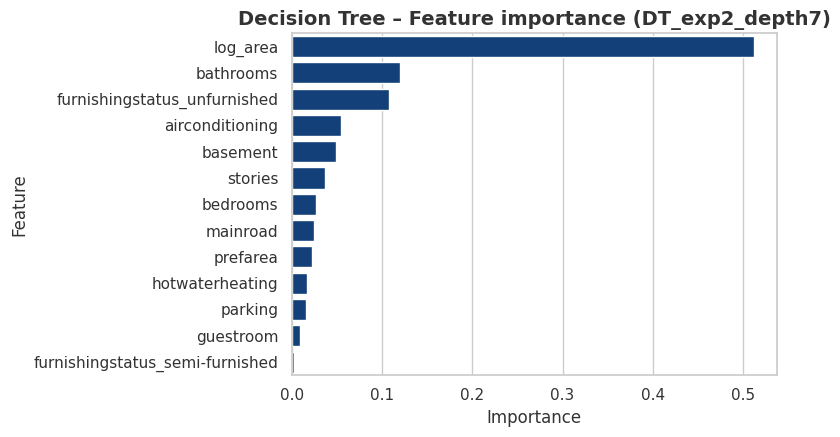

In [ ]:
# === DECISION TREE – CHỌN BEST MODEL & FEATURE IMPORTANCE ===

# df_dt phải tồn tại từ cell 3
best_row_dt = df_dt.loc[df_dt["R2_test"].idxmax()]
best_dt_name = best_row_dt["Experiment"]

print(">>> Best Decision Tree experiment based on Test R²:")
display(best_row_dt.to_frame().T)

# map tên → model object
dt_model_dict = {
    "DT_exp0_baseline":        dt_base,
    "DT_exp1_depth5":          dt_exp1,
    "DT_exp2_depth7":          dt_exp2,
    "DT_exp3_depth4_leaf4":    dt_exp3,
    "DT_exp4_randomSearch":    dt_best
}

dt_best_model = dt_model_dict[best_dt_name]

# Feature importance cho best Decision Tree
plot_feature_importance(
    dt_best_model,
    feature_names,
    top_n=15,
    title=f"Decision Tree – Feature importance ({best_dt_name})"
)


11. Model 4: RANDOM FOREST

In [ ]:
# === RANDOM FOREST REGRESSOR – BASELINE ===

rf_results = []

rf_base = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf_base, rf0_tr, rf0_val, rf0_te = run_tree_experiment(
    "RF_exp0_baseline", rf_base
)
rf_results.append(["RF_exp0_baseline",
                   *rf0_tr, *rf0_val, *rf0_te])

df_rf = pd.DataFrame(rf_results, columns=cols_tree)

print("\n>>> Random Forest – Baseline only:")
display(df_rf)



=== RF_exp0_baseline ===
Train (RMSE, MAE, MAPE, R2): (np.float64(411780.6720455246), 275531.3443775459, np.float64(5.882315869171846), 0.9426739116634244)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1032371.1833369837), 750987.6872477274, np.float64(15.890275938557021), 0.6241276560223566)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1329329.4580293691), 992649.0156948919, np.float64(20.99284574984967), 0.6065897237785774)

>>> Random Forest – Baseline only:


,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
0,RF_exp0_baseline,411780.672046,275531.344378,5.882316,0.942674,1.032371e+06,750987.687248,15.890276,0.624128,1.329329e+06,992649.015695,20.992846,0.60659


11.2. Random Forest 3 experiments

In [ ]:
# === RANDOM FOREST REGRESSOR – 3 EXPERIMENTS ===

# EXP 1
rf_exp1 = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_exp1, rf1_tr, rf1_val, rf1_te = run_tree_experiment(
    "RF_exp1_depth8", rf_exp1
)
rf_results.append(["RF_exp1_depth8",
                   *rf1_tr, *rf1_val, *rf1_te])

# EXP 2
rf_exp2 = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf_exp2, rf2_tr, rf2_val, rf2_te = run_tree_experiment(
    "RF_exp2_depth12", rf_exp2
)
rf_results.append(["RF_exp2_depth12",
                   *rf2_tr, *rf2_val, *rf2_te])

# EXP 3
rf_exp3 = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
rf_exp3, rf3_tr, rf3_val, rf3_te = run_tree_experiment(
    "RF_exp3_depth6_reg", rf_exp3
)
rf_results.append(["RF_exp3_depth6_reg",
                   *rf3_tr, *rf3_val, *rf3_te])

df_rf = pd.DataFrame(rf_results, columns=cols_tree)

print("\n>>> Random Forest – Baseline + 3 experiments:")
display(df_rf.sort_values("R2_test", ascending=False))



=== RF_exp1_depth8 ===
Train (RMSE, MAE, MAPE, R2): (np.float64(646378.0718268966), 442104.0676653392, np.float64(9.702430610400873), 0.8587483200035185)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1015673.2721279102), 743928.163101741, np.float64(15.435986099503795), 0.6361882904003217)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1336615.6770346912), 1015155.1768292502, np.float64(21.416860374826943), 0.6022652440017167)

=== RF_exp2_depth12 ===
Train (RMSE, MAE, MAPE, R2): (np.float64(549378.3873785998), 370614.3471189, np.float64(8.006470808360602), 0.897961625191964)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1031779.9881314766), 747692.4841988073, np.float64(15.692107833042062), 0.6245580250698088)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1323880.0183726044), 994780.6533622869, np.float64(21.044121691500077), 0.6098085966883178)

=== RF_exp3_depth6_reg ===
Train (RMSE, MAE, MAPE, R2): (np.float64(841819.528347558), 570717.5646691885, np.float64(12.388353400750843), 0.7604156836832)
Val  

,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
2,RF_exp2_depth12,549378.387379,370614.347119,8.006471,0.897962,1.031780e+06,747692.484199,15.692108,0.624558,1.323880e+06,9.947807e+05,21.044122,0.609809
0,RF_exp0_baseline,411780.672046,275531.344378,5.882316,0.942674,1.032371e+06,750987.687248,15.890276,0.624128,1.329329e+06,9.926490e+05,20.992846,0.606590
1,RF_exp1_depth8,646378.071827,442104.067665,9.702431,0.858748,1.015673e+06,743928.163102,15.435986,0.636188,1.336616e+06,1.015155e+06,21.416860,0.602265
3,RF_exp3_depth6_reg,841819.528348,570717.564669,12.388353,0.760416,1.012921e+06,757040.670012,15.504923,0.638157,1.393229e+06,1.056328e+06,22.198580,0.567859


11.3. Random forest RandomizedSearchCV

In [ ]:
# === RANDOM FOREST REGRESSOR – RANDOMIZED SEARCH ===

rf_param_dist = {
    "n_estimators":    [100, 200, 300, 500],
    "max_depth":       [3, 5, 7, 9, None],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf":[1, 2, 4],
    "max_features":    ["auto", "sqrt", 0.5]
}

rf_base_rs = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_rand = RandomizedSearchCV(
    estimator=rf_base_rs,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_rand.fit(Xtr_s, y_train)

print("\nBest params (Random Forest):", rf_rand.best_params_)

rf_best = rf_rand.best_estimator_

rf_best_tr  = eval_log_model(rf_best, Xtr_s,  y_train)
rf_best_val = eval_log_model(rf_best, Xval_s, y_val)
rf_best_te  = eval_log_model(rf_best, Xte_s,  y_test)

exp_name = "RF_exp4_randomSearch"
rf_results = [row for row in rf_results if row[0] != exp_name]

rf_results.append([exp_name,
                   *rf_best_tr, *rf_best_val, *rf_best_te])

df_rf = pd.DataFrame(rf_results, columns=cols_tree)

print("\n>>> Random Forest – All (baseline + 3 exp + randomSearch):")
display(df_rf.sort_values("R2_test", ascending=False))


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/


Best params (Random Forest): {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

>>> Random Forest – All (baseline + 3 exp + randomSearch):


,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
2,RF_exp2_depth12,549378.387379,370614.347119,8.006471,0.897962,1.031780e+06,747692.484199,15.692108,0.624558,1.323880e+06,9.947807e+05,21.044122,0.609809
0,RF_exp0_baseline,411780.672046,275531.344378,5.882316,0.942674,1.032371e+06,750987.687248,15.890276,0.624128,1.329329e+06,9.926490e+05,20.992846,0.606590
1,RF_exp1_depth8,646378.071827,442104.067665,9.702431,0.858748,1.015673e+06,743928.163102,15.435986,0.636188,1.336616e+06,1.015155e+06,21.416860,0.602265
4,RF_exp4_randomSearch,805316.687644,545770.010983,11.690388,0.780743,1.015746e+06,742288.318227,15.218434,0.636136,1.358972e+06,1.007231e+06,21.371545,0.588849
3,RF_exp3_depth6_reg,841819.528348,570717.564669,12.388353,0.760416,1.012921e+06,757040.670012,15.504923,0.638157,1.393229e+06,1.056328e+06,22.198580,0.567859


11.4. Select Best RF + Feature importance

>>> Best Random Forest experiment based on Test R²:


,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
2,RF_exp2_depth12,549378.387379,370614.347119,8.006471,0.897962,1031779.988131,747692.484199,15.692108,0.624558,1323880.018373,994780.653362,21.044122,0.609809


=== Top feature importances ===


,feature,importance
0,log_area,0.484089
1,bathrooms,0.115620
2,furnishingstatus_unfurnished,0.085503
3,stories,0.060171
4,bedrooms,0.048405
5,basement,0.040450
6,airconditioning,0.035666
7,parking,0.034570
8,mainroad,0.029796
9,prefarea,0.028403


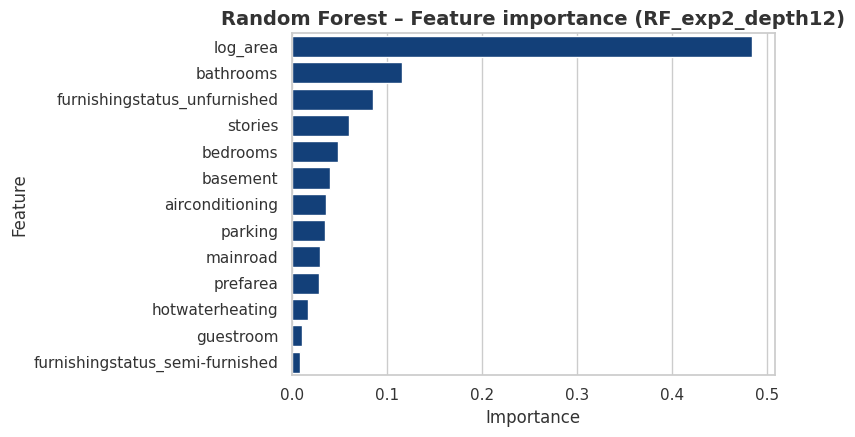

In [ ]:
# === RANDOM FOREST – CHỌN BEST MODEL & FEATURE IMPORTANCE ===

best_row_rf = df_rf.loc[df_rf["R2_test"].idxmax()]
best_rf_name = best_row_rf["Experiment"]

print(">>> Best Random Forest experiment based on Test R²:")
display(best_row_rf.to_frame().T)

rf_model_dict = {
    "RF_exp0_baseline":     rf_base,
    "RF_exp1_depth8":       rf_exp1,
    "RF_exp2_depth12":      rf_exp2,
    "RF_exp3_depth6_reg":   rf_exp3,
    "RF_exp4_randomSearch": rf_best
}

rf_best_model = rf_model_dict[best_rf_name]

plot_feature_importance(
    rf_best_model,
    feature_names,
    top_n=15,
    title=f"Random Forest – Feature importance ({best_rf_name})"
)


12. Model 5: XGBOOST

In [ ]:
# === XGBOOST REGRESSOR – BASELINE ===

xgb_results = []

xgb_base = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
xgb_base, xgb0_tr, xgb0_val, xgb0_te = run_tree_experiment(
    "XGB_exp0_baseline", xgb_base
)
xgb_results.append(["XGB_exp0_baseline",
                    *xgb0_tr, *xgb0_val, *xgb0_te])

df_xgb = pd.DataFrame(xgb_results, columns=cols_tree)

print("\n>>> XGBoost – Baseline only:")
display(df_xgb)



=== XGB_exp0_baseline ===
Train (RMSE, MAE, MAPE, R2): (np.float64(379934.7036183694), 275238.4510082195, np.float64(6.360082784336515), 0.951197921298794)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1011542.2825173523), 784753.2743249611, np.float64(16.63481474118396), 0.6391416930336079)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1230893.4881469328), 917610.2561534727, np.float64(19.77341956540205), 0.6626960784257088)

>>> XGBoost – Baseline only:


,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
0,XGB_exp0_baseline,379934.703618,275238.451008,6.360083,0.951198,1.011542e+06,784753.274325,16.634815,0.639142,1.230893e+06,917610.256153,19.77342,0.662696


12.2. XGBoost 3 experiments

In [ ]:
# === XGBOOST REGRESSOR – 3 EXPERIMENTS ===
# EXP1: deeper
xgb_exp1 = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
xgb_exp1, xgb1_tr, xgb1_val, xgb1_te = run_tree_experiment(
    "XGB_exp1_depth6", xgb_exp1
)
xgb_results.append(["XGB_exp1_depth6",
                    *xgb1_tr, *xgb1_val, *xgb1_te])
# EXP2: small lr, many estimators
xgb_exp2 = XGBRegressor(
    n_estimators=700,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1)
xgb_exp2, xgb2_tr, xgb2_val, xgb2_te = run_tree_experiment(
    "XGB_exp2_lr0.03", xgb_exp2)
xgb_results.append(["XGB_exp2_lr0.03",
                    *xgb2_tr, *xgb2_val, *xgb2_te])
# EXP3: regularization
xgb_exp3 = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1)
xgb_exp3, xgb3_tr, xgb3_val, xgb3_te = run_tree_experiment(
    "XGB_exp3_reg", xgb_exp3)
xgb_results.append(["XGB_exp3_reg",
                    *xgb3_tr, *xgb3_val, *xgb3_te])
df_xgb = pd.DataFrame(xgb_results, columns=cols_tree)
print("\n>>> XGBoost – Baseline + 3 experiments:")
display(df_xgb.sort_values("R2_test", ascending=False))



=== XGB_exp1_depth6 ===
Train (RMSE, MAE, MAPE, R2): (np.float64(78534.06998261384), 46655.709180078644, np.float64(1.1607720774836325), 0.9979148533597295)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1051661.497723933), 791125.3851204156, np.float64(16.87856090348599), 0.6099497381600745)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1280357.3706507883), 969752.5428507202, np.float64(20.922597590059368), 0.6350420285154239)

=== XGB_exp2_lr0.03 ===
Train (RMSE, MAE, MAPE, R2): (np.float64(171055.16625471966), 120321.64892488623, np.float64(2.8848777023602348), 0.9901078023935697)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1052620.8886870916), 794823.3652340517, np.float64(16.93031182075791), 0.6092377573823782)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1289685.5731208255), 973450.6988140232, np.float64(20.964402078154524), 0.6297047632715019)

=== XGB_exp3_reg ===
Train (RMSE, MAE, MAPE, R2): (np.float64(324076.65078678256), 233225.13635304707, np.float64(5.39513146893607), 0.9644928449749821)


,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
0,XGB_exp0_baseline,379934.703618,275238.451008,6.360083,0.951198,1.011542e+06,784753.274325,16.634815,0.639142,1.230893e+06,917610.256153,19.773420,0.662696
3,XGB_exp3_reg,324076.650787,233225.136353,5.395131,0.964493,1.020754e+06,786298.214666,16.870850,0.632540,1.255709e+06,953413.818080,20.551411,0.648959
1,XGB_exp1_depth6,78534.069983,46655.709180,1.160772,0.997915,1.051661e+06,791125.385120,16.878561,0.609950,1.280357e+06,969752.542851,20.922598,0.635042
2,XGB_exp2_lr0.03,171055.166255,120321.648925,2.884878,0.990108,1.052621e+06,794823.365234,16.930312,0.609238,1.289686e+06,973450.698814,20.964402,0.629705


12.3. XGBoost RandomizedSearchCV

In [ ]:
# === XGBOOST REGRESSOR – RANDOMIZED SEARCH (TUNED) ===

xgb_param_dist = {
    "n_estimators": [250, 300, 350, 400], # Focused around previous best 300
    "max_depth":    [2, 3, 4],          # Focused around previous best 3
    "learning_rate":[0.03, 0.05, 0.07], # Focused around previous best 0.05
    "subsample":    [0.5, 0.6, 0.7],    # Focused around previous best 0.6
    "colsample_bytree":[0.5, 0.6, 0.7] # Focused around previous best 0.6
}
xgb_base_rs = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist")
xgb_rand = RandomizedSearchCV(
    estimator=xgb_base_rs,
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1)
xgb_rand.fit(Xtr_s, y_train)
print("\nBest params (XGBoost TUNED):", xgb_rand.best_params_)

xgb_best = xgb_rand.best_estimator_

xgb_best_tr  = eval_log_model(xgb_best, Xtr_s,  y_train)
xgb_best_val = eval_log_model(xgb_best, Xval_s, y_val)
xgb_best_te  = eval_log_model(xgb_best, Xte_s,  y_test)
exp_name_tuned = "XGB_exp4_randomSearch_tuned"
prev_xgb_exp4_results = None
for row in xgb_results:
    if row[0] == old_exp_name:
        prev_xgb_exp4_results = row
        break
xgb_results = [row for row in xgb_results if row[0] != exp_name_tuned]
if prev_xgb_exp4_results is not None:
     if prev_xgb_exp4_results[0] == old_exp_name and prev_xgb_exp4_results not in xgb_results:
        xgb_results.append(prev_xgb_exp4_results)
xgb_results.append([exp_name_tuned,
                    *xgb_best_tr, *xgb_best_val, *xgb_best_te])
df_xgb = pd.DataFrame(xgb_results, columns=cols_tree)
print("\n>>> XGBoost – All (baseline + 3 exp + randomSearch):")
display(df_xgb.sort_values("R2_test", ascending=False))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params (XGBoost TUNED): {'subsample': 0.5, 'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.5}

>>> XGBoost – All (baseline + 3 exp + randomSearch):


,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
5,XGB_exp4_randomSearch_tuned,783947.325397,550387.690951,12.172478,0.792225,1.014543e+06,774672.583984,16.101511,0.636998,1.163692e+06,888072.930465,19.300390,0.698521
4,XGB_exp4_randomSearch,587766.895497,422001.884198,9.561171,0.883203,1.017389e+06,764900.583984,16.053352,0.634958,1.195523e+06,906770.843309,19.634563,0.681803
0,XGB_exp0_baseline,379934.703618,275238.451008,6.360083,0.951198,1.011542e+06,784753.274325,16.634815,0.639142,1.230893e+06,917610.256153,19.773420,0.662696
3,XGB_exp3_reg,324076.650787,233225.136353,5.395131,0.964493,1.020754e+06,786298.214666,16.870850,0.632540,1.255709e+06,953413.818080,20.551411,0.648959
1,XGB_exp1_depth6,78534.069983,46655.709180,1.160772,0.997915,1.051661e+06,791125.385120,16.878561,0.609950,1.280357e+06,969752.542851,20.922598,0.635042
2,XGB_exp2_lr0.03,171055.166255,120321.648925,2.884878,0.990108,1.052621e+06,794823.365234,16.930312,0.609238,1.289686e+06,973450.698814,20.964402,0.629705


12.4. Chọn Best XGBoost + Feature importance

>>> Best XGBoost experiment based on Test R²:


,Experiment,RMSE_train,MAE_train,MAPE_train,R2_train,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
5,XGB_exp4_randomSearch_tuned,783947.325397,550387.690951,12.172478,0.792225,1014542.584636,774672.583984,16.101511,0.636998,1163692.440338,888072.930465,19.30039,0.698521


=== Top feature importances ===


,feature,importance
0,airconditioning,0.175039
1,bathrooms,0.142206
2,mainroad,0.103304
3,furnishingstatus_unfurnished,0.101348
4,log_area,0.099613
5,basement,0.068619
6,bedrooms,0.068255
7,prefarea,0.056378
8,stories,0.051682
9,parking,0.042597


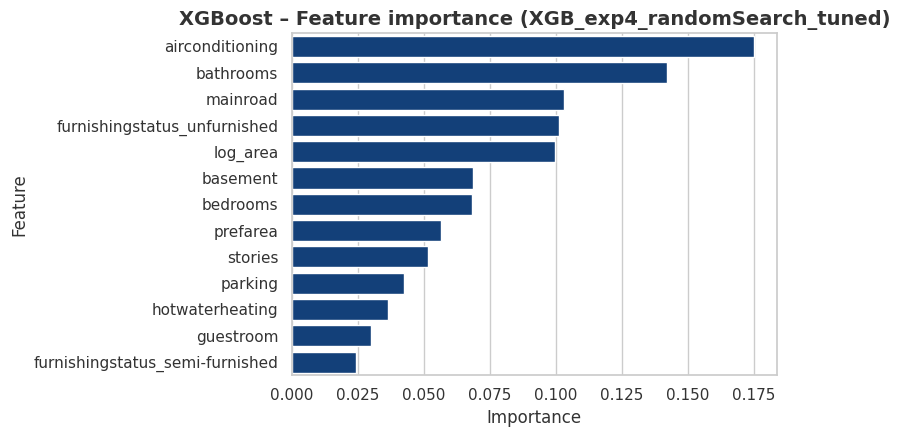

In [ ]:
# === XGBOOST – CHỌN BEST MODEL & FEATURE IMPORTANCE ===

best_row_xgb = df_xgb.loc[df_xgb["R2_test"].idxmax()]
best_xgb_name = best_row_xgb["Experiment"]
print(">>> Best XGBoost experiment based on Test R²:")
display(best_row_xgb.to_frame().T)
xgb_model_dict = {
    "XGB_exp0_baseline":     xgb_base,
    "XGB_exp1_depth6":       xgb_exp1,
    "XGB_exp2_lr0.03":       xgb_exp2,
    "XGB_exp3_reg":          xgb_exp3,
    "XGB_exp4_randomSearch_tuned": xgb_best
}
xgb_best_model = None
if best_xgb_name == "XGB_exp4_randomSearch_tuned":
    xgb_best_model = xgb_best
elif best_xgb_name in xgb_model_dict:
    xgb_best_model = xgb_model_dict[best_xgb_name]
else:
    print(f"Warning: Model object for '{best_xgb_name}' not directly available. Falling back to the currently best-tuned model 'xgb_best' for feature importance.")
    xgb_best_model = xgb_best # Fallback to the latest tuned model
if xgb_best_model is not None:
    plot_feature_importance(
        xgb_best_model,
        feature_names,
        top_n=15,
        title=f"XGBoost – Feature importance ({best_xgb_name})"
    )
else:
    print("Error: No valid XGBoost model object could be retrieved for feature importance plotting.")

13. Evaluation function & drawing function (common for all 2 models - ANN, GMDH-like)

In [ ]:
def eval_log_model(model, Xmat, y_true_log):
    y_pred_log = model.predict(Xmat).ravel()
    y_true = np.exp(y_true_log.values)
    y_pred = np.exp(y_pred_log)

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-9, None))) * 100
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, mape, r2

def plot_pred_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(4,4))
    plt.scatter(y_true, y_pred, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.title(title)
    plt.tight_layout()
    plt.show()


14.1. Hàm build & run ANN (dùng cho mọi experiment)

In [ ]:
from tensorflow.keras import backend as K
def build_ann_model(input_dim,
                    n_layers=2,
                    units_per_layer=[64, 32],
                    activation='relu',
                    dropout_rate=0.0,
                    learning_rate=1e-3,
                    optimizer_name='adam'):

    model = keras.Sequential()
    # Hidden layer 1
    model.add(
        layers.Dense(units_per_layer[0],
                     activation=activation,
                     input_shape=(input_dim,))
    )
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    for i in range(1, n_layers):
        model.add(
            layers.Dense(units_per_layer[i],
                         activation=activation)
        )
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1))
    if optimizer_name.lower() == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
    )
    return model
def run_ann_experiment(name,
                       n_layers,
                       units_per_layer,
                       activation,
                       dropout_rate,
                       batch_size,
                       learning_rate,
                       optimizer_name,
                       max_epochs=1000,
                       patience=30):
    print(f"\n================= {name} =================")
    print("Hyperparams:",
          f"n_layers={n_layers}, units={units_per_layer},",
          f"act={activation}, dropout={dropout_rate},",
          f"batch={batch_size}, lr={learning_rate}, opt={optimizer_name}")
    input_dim = Xtr_s.shape[1]
    # 1. Build model
    model = build_ann_model(
        input_dim=input_dim,
        n_layers=n_layers,
        units_per_layer=units_per_layer,
        activation=activation,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        optimizer_name=optimizer_name
    )
    model.summary()
    # 2. EarlyStopping
    es = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )
    # 3. Train
    history = model.fit(
        Xtr_s, y_train,
        validation_data=(Xval_s, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=0
    )
    print("Stopped at epoch:", len(history.history['loss']))
    # 4. Evaluate on train / val / test (using common eval_log_model)
    ann_train = eval_log_model(model, Xtr_s,  y_train)
    ann_val   = eval_log_model(model, Xval_s, y_val)
    ann_test  = eval_log_model(model, Xte_s,  y_test)

    print("Train (RMSE, MAE, MAPE, R2):", ann_train)
    print("Val   (RMSE, MAE, MAPE, R2):", ann_val)
    print("Test  (RMSE, MAE, MAPE, R2):", ann_test)

    # 5. Combine Plot Actual vs Predicted – Test and Loss curve into one figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # 1 row, 2 columns
    # Plot 1: Actual vs Predicted – Test
    y_test_true = np.exp(y_test.values)
    y_pred      = np.exp(model.predict(Xte_s).ravel())
    axes[0].scatter(y_test_true, y_pred, alpha=0.5)
    lims = [min(y_test_true.min(), y_pred.min()),
            max(y_test_true.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--')
    axes[0].set_title(f"{name} – Actual vs Predicted (Test)")
    axes[0].set_xlabel("Actual price")
    axes[0].set_ylabel("Predicted price")

    # Plot 2: Loss curve
    axes[1].plot(history.history['loss'], label='Train loss')
    axes[1].plot(history.history['val_loss'], label='Val loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE loss')
    axes[1].set_title(f'{name} Training Curve')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    return model, ann_train, ann_val, ann_test, history

14.2. Models 6: ANN Baseline


================= ANN_exp0_baseline =================
Hyperparams: n_layers=2, units=[64, 32], act=relu, dropout=0.0, batch=32, lr=0.001, opt=adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch: 486
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Train (RMSE, MAE, MAPE, R2): (np.float64(608988.7040774061), 455123.56173069344, np.float64(9.95354921629865), 0.8746169394183483)
Val   (RMSE, MAE, MAPE, R2): (np.float64(2700385.1757282964), 1719523.8591977663, np.float64(35.805470532974425), -1.5716985236546903)
Test  (RMSE, MAE, MAPE, R2): (np.float64(5826714.328636408), 2353212.2423920045, np.float64(43.46804158557912), -6.558365588182795)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


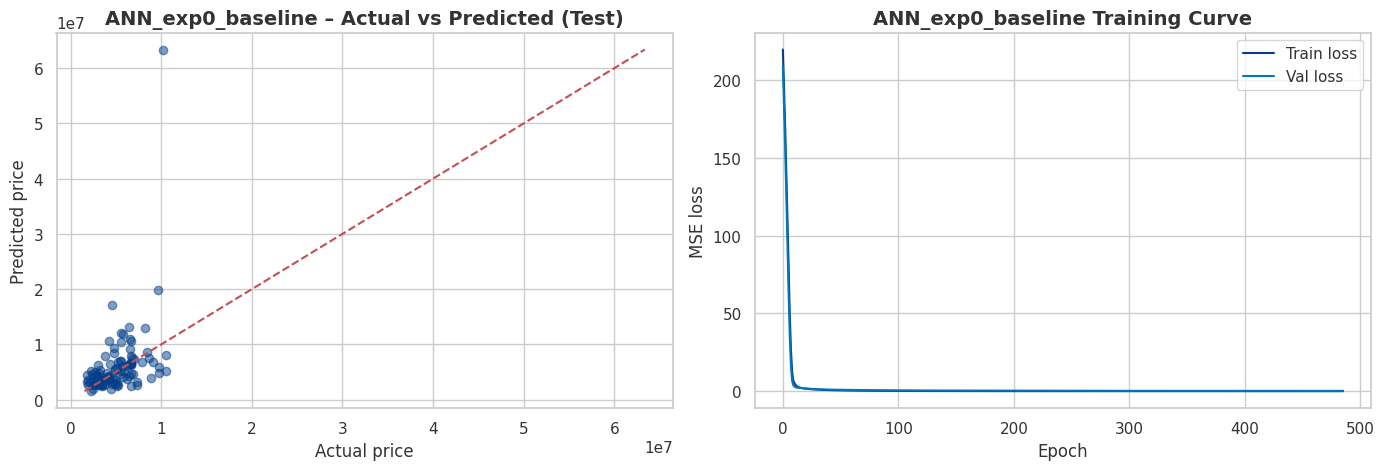

In [ ]:
# === ANN BASELINE (Exp0) ===

# ann_results = [] # Reset list if rerunning from scratch

ann_base, ann_base_tr, ann_base_val, ann_base_te, ann_base_history = run_ann_experiment(
    name           ="ANN_exp0_baseline",
    n_layers       =2,
    units_per_layer=[64, 32],
    activation     ="relu",
    dropout_rate   =0.0,
    batch_size     =32,
    learning_rate  =1e-3,
    optimizer_name ="adam",
    max_epochs     =1000,
    patience       =30
)


14.3. ANN Experiment 1–3 (manual tuning)


================= ANN_exp1_small =================
Hyperparams: n_layers=1, units=[32], act=relu, dropout=0.0, batch=32, lr=0.001, opt=adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch: 500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Train (RMSE, MAE, MAPE, R2): (np.float64(1206624.0112732423), 867852.5118921675, np.float64(18.79855924004274), 0.5077742616509716)
Val   (RMSE, MAE, MAPE, R2): (np.float64(2968446.109064732), 1913793.7697084828, np.float64(37.576178783986094), -2.107613239119286)
Test  (RMSE, MAE, MAPE, R2): (np.float64(3097807.6249057692), 2205677.3668186096, np.float64(45.19090668026448), -1.1364332626074)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


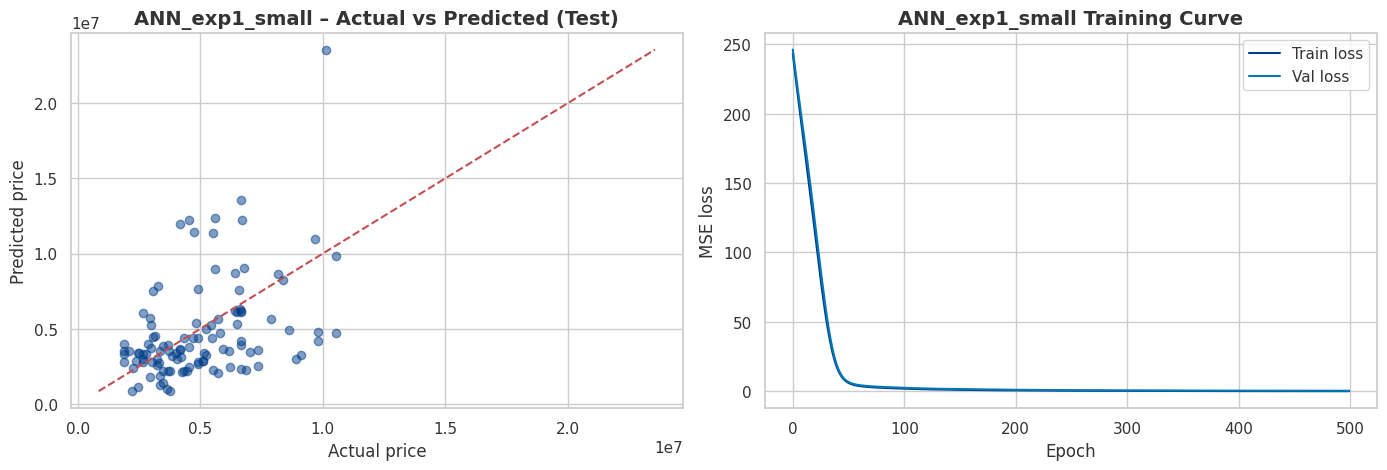


================= ANN_exp2_medium_dropout =================
Hyperparams: n_layers=2, units=[64, 32], act=relu, dropout=0.2, batch=32, lr=0.0005, opt=adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch: 282
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Train (RMSE, MAE, MAPE, R2): (np.float64(3412767.896132151), 1721427.474805406, np.float64(34.18579480274781), -2.9376208671802164)
Val   (RMSE, MAE, MAPE, R2): (np.float64(3260061.8159763557), 2101485.5165124605, np.float64(40.6833461673114), -2.7481787600995835)
Test  (RMSE, MAE, MAPE, R2): (np.float64(5793444.50086141), 3069166.7022543903, np.float64(59.33982325822972), -6.472297321054353)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


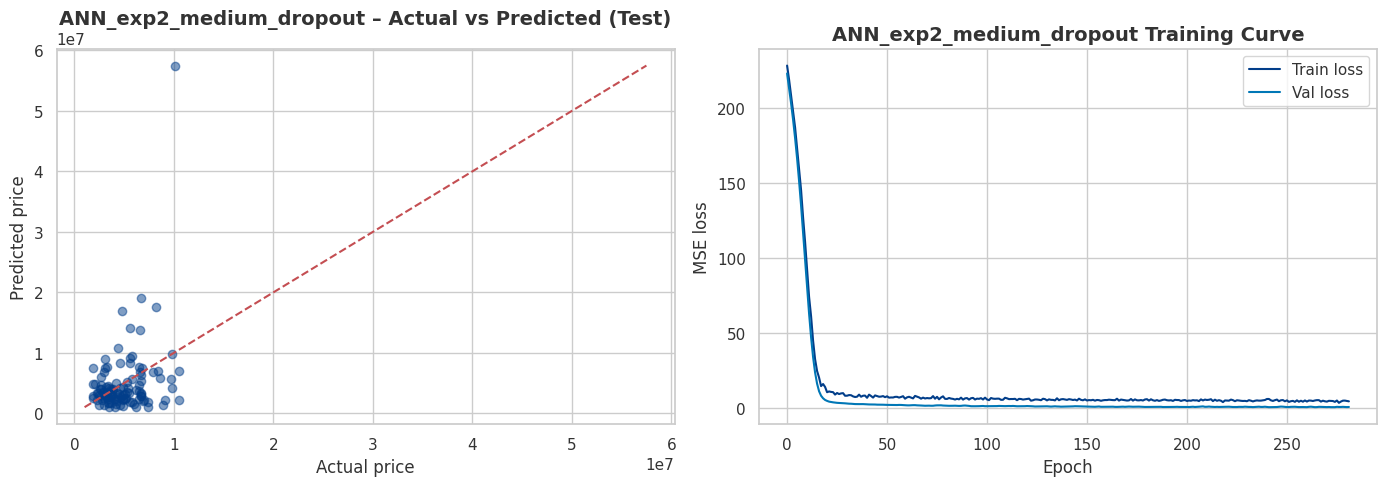


================= ANN_exp3_tanh_stronger_dropout =================
Hyperparams: n_layers=2, units=[64, 32], act=tanh, dropout=0.3, batch=16, lr=0.0005, opt=adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Stopped at epoch: 101
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Train (RMSE, MAE, MAPE, R2): (np.float64(1145023.2188052954), 806837.0910944262, np.float64(17.548444587110378), 0.5567497601928978)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1147380.6653746308), 868056.15216587, np.float64(17.662248790452953), 0.5357160402945342)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1506940.8050201365), 1101493.4946855821, np.float64(22.28423395638186), 0.49443985707494564)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


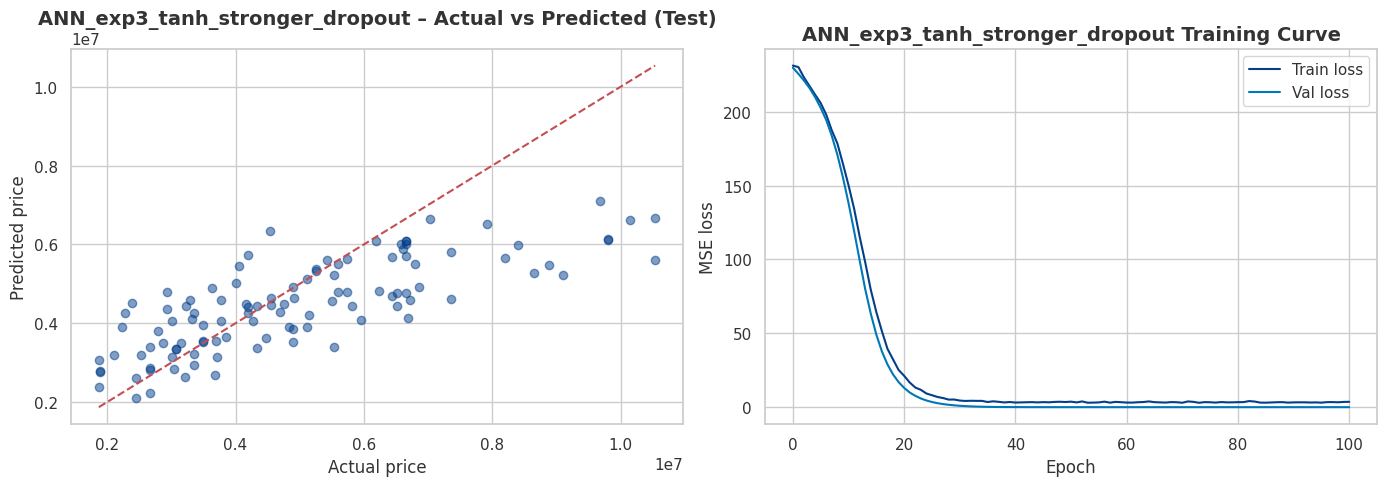

In [ ]:
# === ANN EXPERIMENT 1 – mạng nhỏ, đơn giản, ít overfitting hơn ===
ann_exp1, ann1_tr, ann1_val, ann1_te, ann1_history = run_ann_experiment(
    name           ="ANN_exp1_small",
    n_layers       =1,
    units_per_layer=[32],
    activation     ="relu",
    dropout_rate   =0.0,
    batch_size     =32,
    learning_rate  =1e-3,
    optimizer_name ="adam",
    max_epochs     =500,
    patience       =30
)

# === ANN EXPERIMENT 2 – mạng lớn hơn, thêm dropout để regularize ===
ann_exp2, ann2_tr, ann2_val, ann2_te, ann2_history = run_ann_experiment(
    name           ="ANN_exp2_medium_dropout",
    n_layers       =2,
    units_per_layer=[64, 32],
    activation     ="relu",
    dropout_rate   =0.2,
    batch_size     =32,
    learning_rate  =5e-4,
    optimizer_name ="adam",
    max_epochs     =800,
    patience       =40
)

# === ANN EXPERIMENT 3 – thử activation 'tanh' + dropout mạnh hơn ===
ann_exp3, ann3_tr, ann3_val, ann3_te, ann3_history = run_ann_experiment(
    name           ="ANN_exp3_tanh_stronger_dropout",
    n_layers       =2,
    units_per_layer=[64, 32],
    activation     ="tanh",
    dropout_rate   =0.3,
    batch_size     =16,
    learning_rate  =5e-4,
    optimizer_name ="adam",
    max_epochs     =800,
    patience       =40
)


Baseline vs best (visualize)

=== Comparison: Actual vs Predicted Prices (Test Set) - ANN Models ===
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


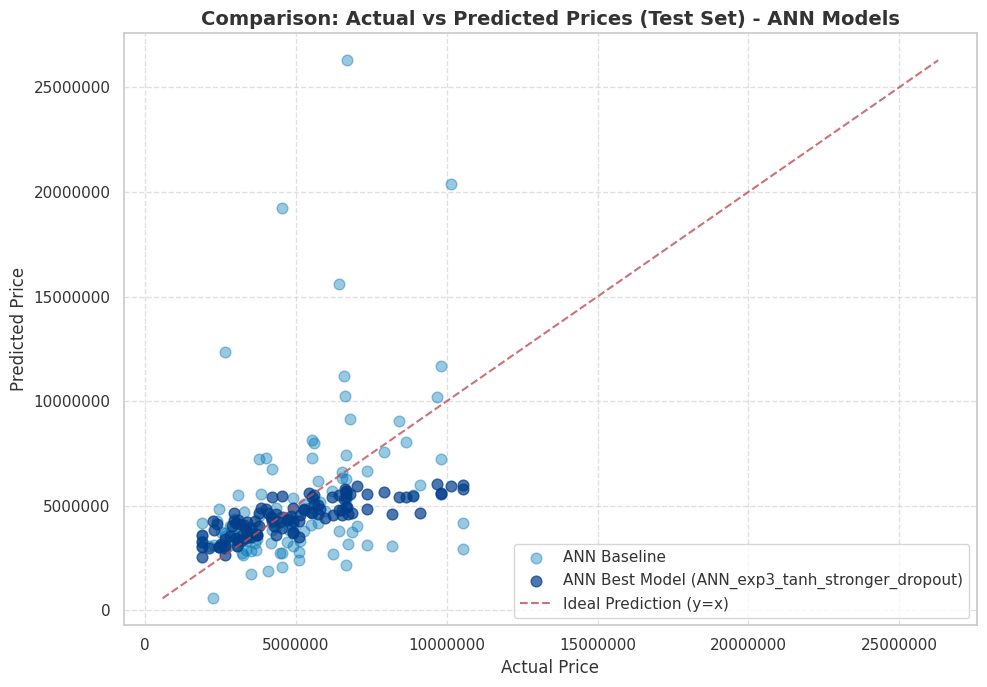

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Import pandas for DataFrame operations

print("=== Comparison: Actual vs Predicted Prices (Test Set) - ANN Models ===")

# Recalculate predictions for plotting
y_test_true = np.exp(y_test.values)

y_pred_base = np.exp(ann_base.predict(Xte_s).ravel())

# --- Code to define best_ann_model and best_exp_name (moved from cell qxdyYcKG37Mn) ---
# 1. Aggregate results from ANN experiments into a dictionary
results_ann = {
    "ANN_exp0_baseline":              ann_base_te,
    "ANN_exp1_small":                 ann1_te,
    "ANN_exp2_medium_dropout":        ann2_te,
    "ANN_exp3_tanh_stronger_dropout": ann3_te,
}

# 2. Convert to DataFrame for easier processing and sorting
rows = []
for name, (rmse, mae, mape, r2) in results_ann.items():
    rows.append({
        "Experiment": name,
        "RMSE": float(rmse),
        "MAE":  float(mae),
        "MAPE": float(mape),
        "R2":   float(r2)
    })

df_ann_results = (
    pd.DataFrame(rows)
      .sort_values("R2", ascending=False) # Sort to find the best model based on R2
      .reset_index(drop=True)
)

# Get the row corresponding to the best performing ANN experiment on the Test set
best_row = df_ann_results.loc[df_ann_results["R2"].idxmax()]
best_exp_name = best_row["Experiment"]

# Create a dictionary to map experiment names to their respective model objects
ann_model_dict = {
    "ANN_exp0_baseline":              ann_base,
    "ANN_exp1_small":                 ann_exp1,
    "ANN_exp2_medium_dropout":        ann_exp2,
    "ANN_exp3_tanh_stronger_dropout": ann_exp3,
}

# Assign the best ANN model object based on the best experiment name
best_ann_model = ann_model_dict[best_exp_name]
# --- End of moved code ---

y_pred_best = np.exp(best_ann_model.predict(Xte_s).ravel())

# Define colors - using thuy_palette for consistency
dark_color = "#023E8A"   # Xanh tím than
light_color = "#0077B6"  # Xanh biển sâu

plt.figure(figsize=(10, 7))

# Plot for ANN Baseline (lighter color)
plt.scatter(y_test_true, y_pred_base, alpha=0.4, color=light_color, label='ANN Baseline', s=60)

# Plot for Best ANN Model (darker color)
plt.scatter(y_test_true, y_pred_best, alpha=0.7, color=dark_color, label=f'ANN Best Model ({best_exp_name})', s=60)

# Plot ideal prediction line
min_val = min(y_test_true.min(), y_pred_base.min(), y_pred_best.min())
max_val = max(y_test_true.max(), y_pred_base.max(), y_pred_best.max())
lims = [min_val, max_val]
plt.plot(lims, lims, 'r--', alpha=0.8, label='Ideal Prediction (y=x)')

plt.title('Comparison: Actual vs Predicted Prices (Test Set) - ANN Models')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

14.4. Choose the best ANN to include in the final comparison table

In [ ]:
# 1. Combine the results of 4 experiments into 1 dict
results_ann = {
    "ANN_exp0_baseline":              ann_base_te,
    "ANN_exp1_small":                 ann1_te,
    "ANN_exp2_medium_dropout":        ann2_te,
    "ANN_exp3_tanh_stronger_dropout": ann3_te,
}

# 2. Convert to DataFrame for readability
rows = []
for name, (rmse, mae, mape, r2) in results_ann.items():
    rows.append({
        "Experiment": name,
        "RMSE": float(rmse),
        "MAE":  float(mae),
        "MAPE": float(mape),
        "R2":   float(r2)
    })

df_ann_results = (
    pd.DataFrame(rows)
      .sort_values("R2", ascending=False)
      .reset_index(drop=True)
)

display(df_ann_results)

best_row = df_ann_results.loc[df_ann_results["R2"].idxmax()]
best_exp_name = best_row["Experiment"]

print(">>> Best ANN experiment based on Test R²:")
display(best_row.to_frame().T)



,Experiment,RMSE,MAE,MAPE,R2
0,ANN_exp3_tanh_stronger_dropout,1.600926e+06,1.159225e+06,23.087202,0.429412
1,ANN_exp0_baseline,3.482732e+06,2.029376e+06,42.168767,-1.700354
2,ANN_exp1_small,3.507787e+06,2.511919e+06,52.049022,-1.739345
3,ANN_exp2_medium_dropout,8.057470e+06,3.343281e+06,57.950863,-13.453661


>>> Best ANN experiment based on Test R²:


,Experiment,RMSE,MAE,MAPE,R2
0,ANN_exp3_tanh_stronger_dropout,1600925.696744,1159225.15753,23.087202,0.429412



Bạn có thể chọn **ANN_exp3_tanh_stronger_dropout** là mô hình ANN tốt nhất để đưa vào phần so sánh cuối.


15.Model 7: GMDH-liked

Polynomial Regression above: poly deg=2 + LinearRegression uses all terms.

GMDH-like: poly deg=2 + Lasso (L1) → automatically remove unimportant terms → different from the poly version above, close to the spirit of GMDH self-organizing

15.1.GMDH-liked build & run function

In [ ]:
def gmdh_diagnostics(model, poly,
                     Xtr_s, y_train,
                     Xte_s, y_test,
                     title="GMDH-like"):
    # 1. Poly transformation
    Xtr_g = poly.transform(Xtr_s)
    Xte_g = poly.transform(Xte_s)
    # 2. Predict on log scale, then back-transform
    y_tr_log_pred = model.predict(Xtr_g)
    y_te_log_pred = model.predict(Xte_g)
    y_tr_true = np.exp(y_train.values)
    y_te_true = np.exp(y_test.values)
    y_tr_pred = np.exp(y_tr_log_pred)
    y_te_pred = np.exp(y_te_log_pred)
    # 3. Residuals train
    resid_tr = y_tr_true - y_tr_pred
    # 4. Plot
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    # 4.1 Histogram residuals (Train)
    sns.histplot(resid_tr, kde=True, ax=axes[0])
    axes[0].set_title(f"{title} – Train residuals")
    axes[0].set_xlabel("Error (Actual - Predicted)")
    # 4.2 Actual vs Predicted (Test)
    axes[1].scatter(y_te_true, y_te_pred, alpha=0.5)
    lims = [min(y_te_true.min(), y_te_pred.min()),
            max(y_te_true.max(), y_te_pred.max())]
    axes[1].plot(lims, lims, 'r--')
    axes[1].set_title(f"{title} – Test vs Predicted")
    axes[1].set_xlabel("Actual (Test)")
    axes[1].set_ylabel("Predicted")
    plt.tight_layout()
    plt.show()
def run_gmdh_like_single(name,
                         degree=2,
                         alpha=0.001,
                         max_iter=20000):
    print(f"\n================= {name} =================")
    print(f"degree={degree}, alpha={alpha}")
    # 1. Polynomial transform
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Xtr_gmdh  = poly.fit_transform(Xtr_s)
    Xval_gmdh = poly.transform(Xval_s)
    Xte_gmdh  = poly.transform(Xte_s)
    print("Poly feature shape (train):", Xtr_gmdh.shape)
    # 2. Lasso on poly features (self-organizing GMDH style)
    gmdh_model = Lasso(alpha=alpha,
                       max_iter=max_iter,
                       random_state=42)
    gmdh_model.fit(Xtr_gmdh, y_train)
    # 3.Evaluate on Train / Val / Test (original price scale)
    gmdh_train = eval_log_model(gmdh_model, Xtr_gmdh,  y_train)
    gmdh_val   = eval_log_model(gmdh_model, Xval_gmdh, y_val)
    gmdh_test  = eval_log_model(gmdh_model, Xte_gmdh,  y_test)
    print("Train (RMSE, MAE, MAPE, R2):", gmdh_train)
    print("Val   (RMSE, MAE, MAPE, R2):", gmdh_val)
    print("Test  (RMSE, MAE, MAPE, R2):", gmdh_test)
    # 4. Plot Actual vs Predicted – Test
    y_test_true = np.exp(y_test.values)
    y_pred_gmdh = np.exp(gmdh_model.predict(Xte_gmdh))
    plot_pred_vs_actual(y_test_true, y_pred_gmdh,
                        f"{name} – Actual vs Predicted (Test)")
    # 5. Residual diagnostics (Train residuals + Test vs Predicted)
    gmdh_diagnostics(gmdh_model, poly,
                     Xtr_s, y_train,
                     Xte_s, y_test,
                     title=name)

    return poly, gmdh_model, gmdh_train, gmdh_val, gmdh_test


15.2. GMDH-like Baseline


================= GMDH_like_exp0_baseline =================
degree=2, alpha=0.001
Poly feature shape (train): (348, 104)
Train (RMSE, MAE, MAPE, R2): (np.float64(681542.84185427), 493136.5756379357, np.float64(11.172543452549121), 0.8429612918043006)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1183252.9213250747), 873020.5443319354, np.float64(18.594592678372944), 0.5062310278378049)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1408442.49054899), 1073255.9355208373, np.float64(22.946406109239238), 0.5583698861623536)


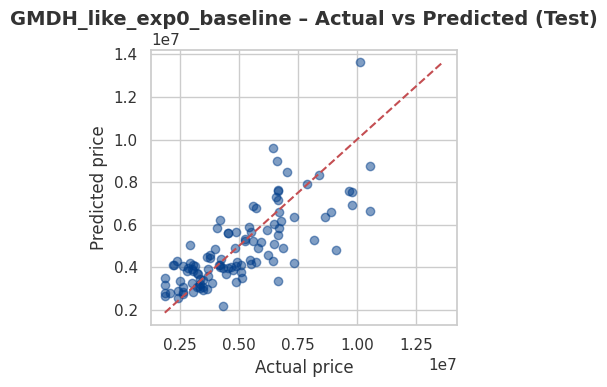

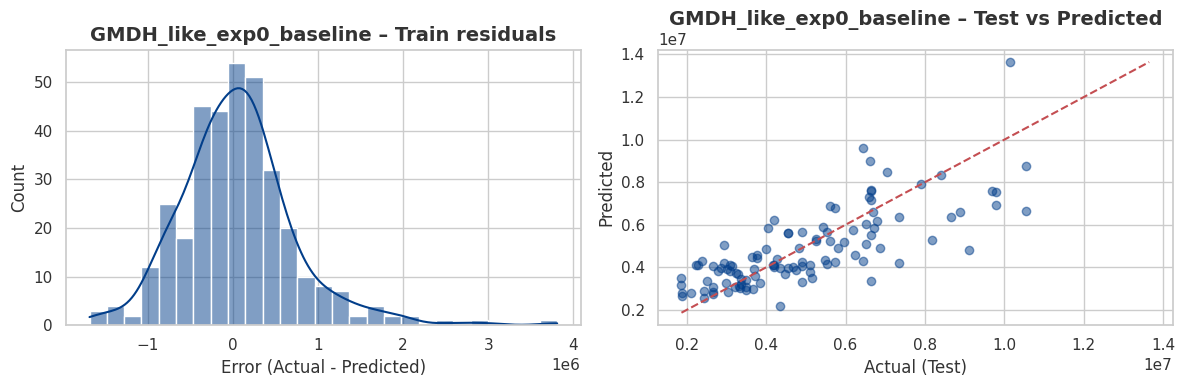

In [ ]:
# GMDH-like – BASELINE
poly_g_base, gmdh_base_model, gmdh_base_tr, gmdh_base_val, gmdh_base_te = run_gmdh_like_single(
    name   ="GMDH_like_exp0_baseline",
    degree =2,
    alpha  =0.001
)

### GMDH-like Experiment 1–3 (manual tuning)


================= GMDH_like_exp1_alpha_strong =================
degree=2, alpha=0.01
Poly feature shape (train): (348, 104)
Train (RMSE, MAE, MAPE, R2): (np.float64(847291.5716836872), 591740.9659859746, np.float64(13.06089147843736), 0.7572908411558308)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1016642.8673113998), 753334.9588854174, np.float64(15.410897656637633), 0.6354933455505611)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1283096.082575478), 977805.361390747, np.float64(20.96081213967124), 0.6334790527975309)


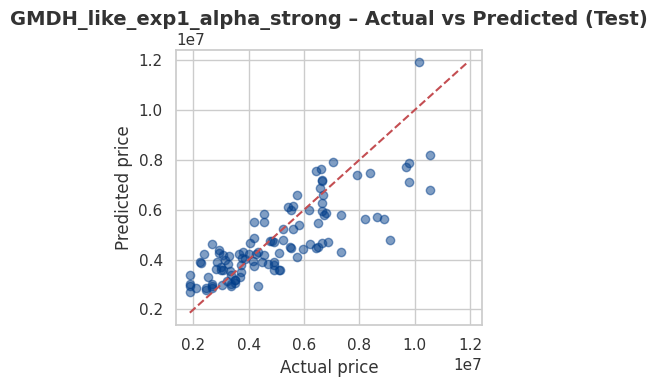

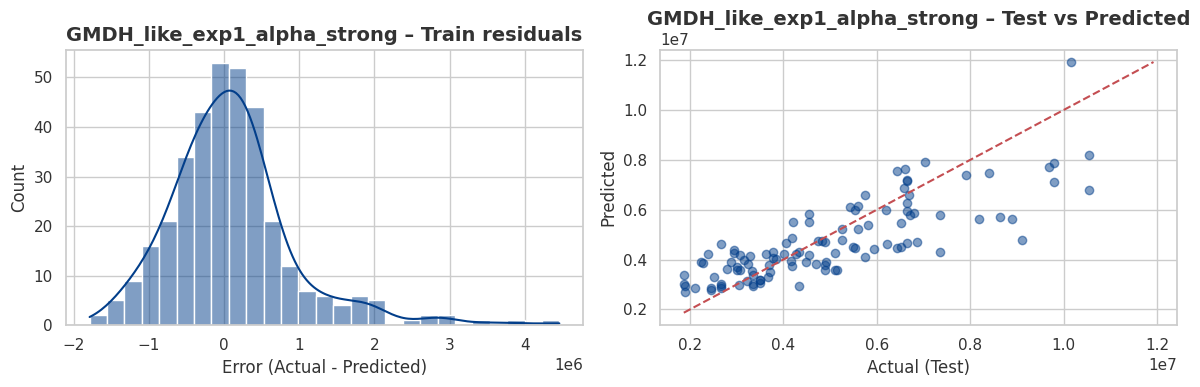


================= GMDH_like_exp2_alpha_small =================
degree=2, alpha=0.0001
Poly feature shape (train): (348, 104)
Train (RMSE, MAE, MAPE, R2): (np.float64(669302.0609287585), 483781.20588336437, np.float64(10.99080127506644), 0.8485515904083323)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1275163.334614784), 936395.612955552, np.float64(20.317209291816322), 0.4265437918714938)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1477879.7954421625), 1104225.0989173907, np.float64(23.792575422990346), 0.5137510620319804)


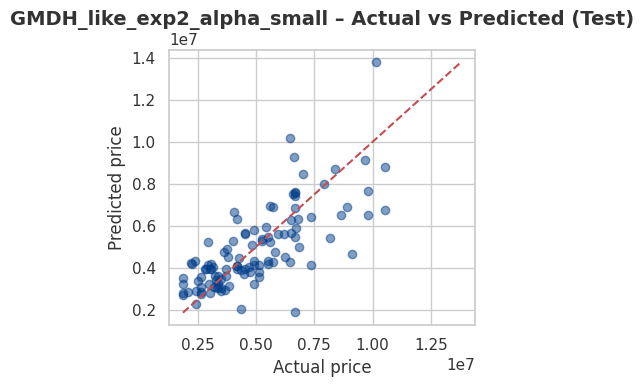

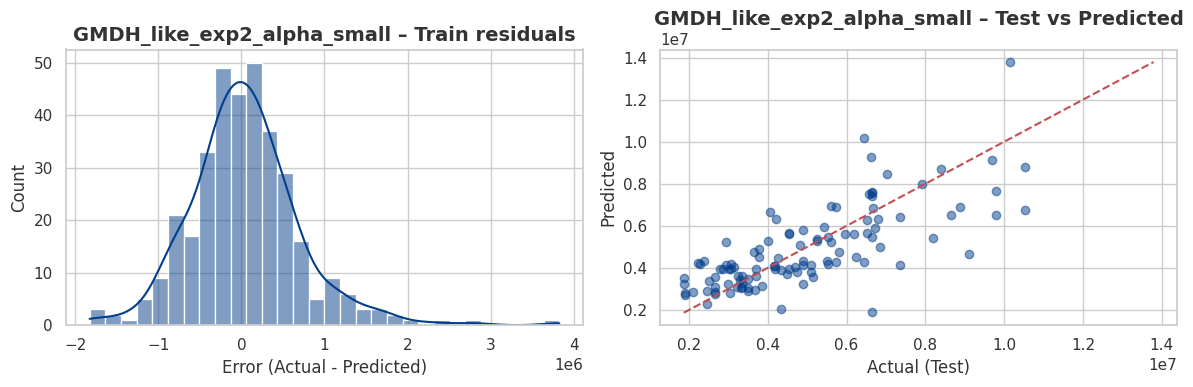


================= GMDH_like_exp3_deg3 =================
degree=3, alpha=0.001
Poly feature shape (train): (348, 559)
Train (RMSE, MAE, MAPE, R2): (np.float64(405615.8762443326), 270074.8847096473, np.float64(6.663869600723073), 0.9443775283598109)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1383482.3278861572), 998563.9192721024, np.float64(21.001065297392067), 0.3249812177311602)
Test  (RMSE, MAE, MAPE, R2): (np.float64(2116032.9248713804), 1327349.1691983503, np.float64(26.542962687011457), 0.0031603959515903446)


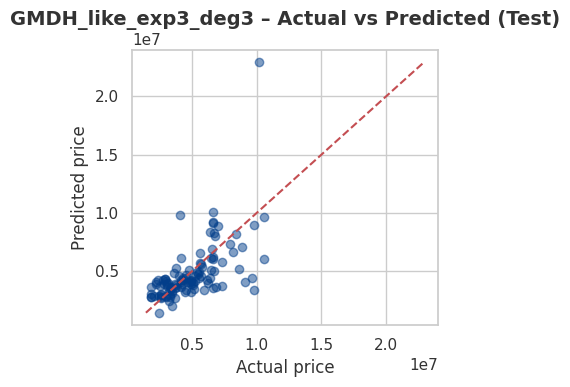

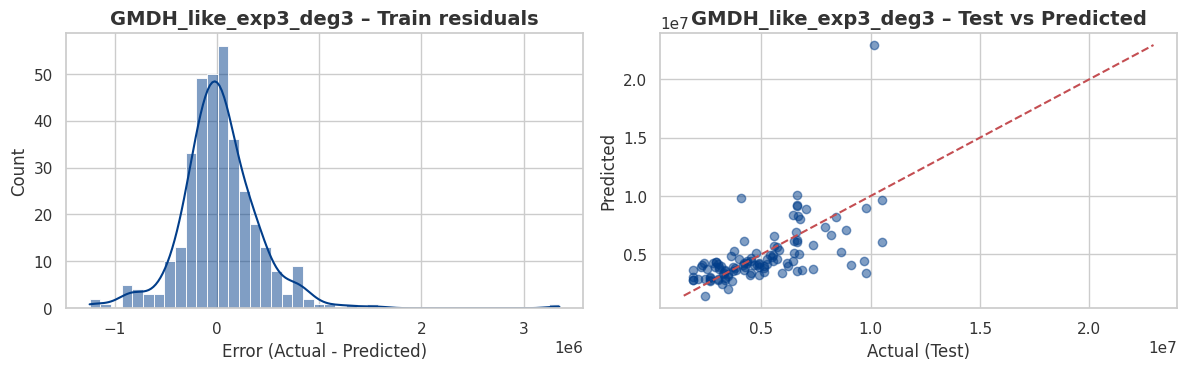


================= GMDH_like_manual_tuned_best =================
degree=2, alpha=0.012
Poly feature shape (train): (348, 104)
Train (RMSE, MAE, MAPE, R2): (np.float64(877571.5537808797), 612177.7649403927, np.float64(13.442188449431116), 0.7396332830390726)
Val   (RMSE, MAE, MAPE, R2): (np.float64(1009727.0156963759), 744447.4669616609, np.float64(15.18333319139834), 0.6404356900482093)
Test  (RMSE, MAE, MAPE, R2): (np.float64(1282316.2022721851), 977545.9565169162, np.float64(20.99922200928674), 0.6339244685418488)


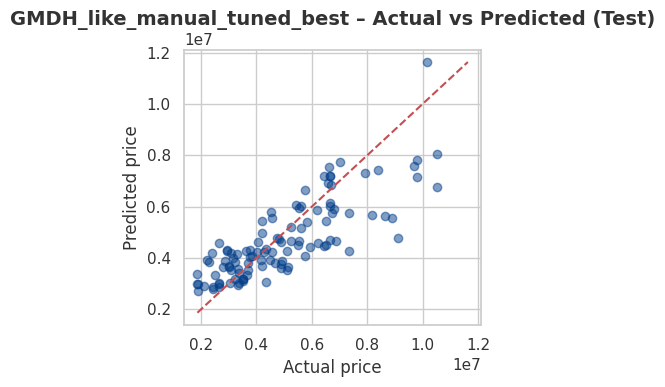

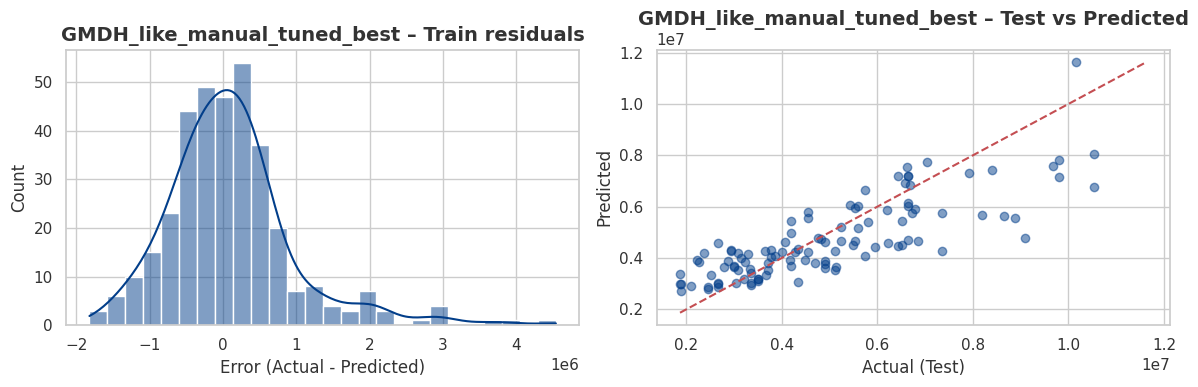

In [ ]:
gmdh_results_list = [] # Initialize a list to store all GMDH results for a DataFrame later

# GMDH-like – EXPERIMENT 1 (alpha lớn hơn → ít term hơn, giảm overfitting)
poly_g1, gmdh1_model, gmdh1_tr, gmdh1_val, gmdh1_te = run_gmdh_like_single(
    name   ="GMDH_like_exp1_alpha_strong",
    degree =2,
    alpha  =0.01
)
gmdh_results_list.append(["GMDH_like_exp1_alpha_strong", *gmdh1_tr, *gmdh1_val, *gmdh1_te])

# GMDH-like – EXPERIMENT 2 (alpha nhỏ hơn → nhiều term đa thức hơn)
poly_g2, gmdh2_model, gmdh2_tr, gmdh2_val, gmdh2_te = run_gmdh_like_single(
    name   ="GMDH_like_exp2_alpha_small",
    degree =2,
    alpha  =0.0001
)
gmdh_results_list.append(["GMDH_like_exp2_alpha_small", *gmdh2_tr, *gmdh2_val, *gmdh2_te])

# GMDH-like – EXPERIMENT 3 (degree=3, alpha điều chỉnh)
poly_g3, gmdh3_model, gmdh3_tr, gmdh3_val, gmdh3_te = run_gmdh_like_single(
    name   ="GMDH_like_exp3_deg3",
    degree =3,
    alpha  =0.001
)
gmdh_results_list.append(["GMDH_like_exp3_deg3", *gmdh3_tr, *gmdh3_val, *gmdh3_te])

# Re-introducing the best manual tuned result
poly_g_manual_tuned, gmdh_manual_tuned_model, gmdh_manual_tuned_tr, gmdh_manual_tuned_val, gmdh_manual_tuned_te = run_gmdh_like_single(
    name   ="GMDH_like_manual_tuned_best",
    degree =2,
    alpha  =0.012 # This alpha value produced the R2 = 0.633924
)


### 15.4. Select the best GMDH-like to include in the final comparison table

In [ ]:
# COLLECT THE RESULTS OF GMDH-LIKE EXPERIMENTS (based on Test R²)
results_gmdh_test = {
    "GMDH_like_exp0_baseline":        gmdh_base_te,
    "GMDH_like_exp1_alpha_strong":    gmdh1_te,
    "GMDH_like_exp2_alpha_small":     gmdh2_te,
    "GMDH_like_exp3_deg3":            gmdh3_te,
    "GMDH_like_manual_tuned_best":    gmdh_manual_tuned_te, # Re-introduced the best tuned model
}
rows = []
for name, (rmse, mae, mape, r2) in results_gmdh_test.items():
    rows.append({
        "Experiment": name,
        "RMSE": float(rmse),
        "MAE":  float(mae),
        "MAPE": float(mape),
        "R2":   float(r2)
    })
df_gmdh_results = (pd.DataFrame(rows)
                   .sort_values("R2", ascending=False)
                   .reset_index(drop=True))
display(df_gmdh_results)

best_gmdh_row  = df_gmdh_results.loc[df_gmdh_results["R2"].idxmax()]
best_gmdh_name = best_gmdh_row["Experiment"]
# Update gmdh_best_train, gmdh_best_val, gmdh_best_test so LguHNCVElPHq can use the actual best GMDH
if best_gmdh_name == "GMDH_like_exp0_baseline":
    gmdh_best_train, gmdh_best_val, gmdh_best_test = gmdh_base_tr, gmdh_base_val, gmdh_base_te
elif best_gmdh_name == "GMDH_like_exp1_alpha_strong":
    gmdh_best_train, gmdh_best_val, gmdh_best_test = gmdh1_tr, gmdh1_val, gmdh1_te
elif best_gmdh_name == "GMDH_like_exp2_alpha_small":
    gmdh_best_train, gmdh_best_val, gmdh_best_test = gmdh2_tr, gmdh2_val, gmdh2_te
elif best_gmdh_name == "GMDH_like_exp3_deg3":
    gmdh_best_train, gmdh_best_val, gmdh_best_test = gmdh3_tr, gmdh3_val, gmdh3_te
elif best_gmdh_name == "GMDH_like_manual_tuned_best": # This is the re-introduced best model
    gmdh_best_train, gmdh_best_val, gmdh_best_test = gmdh_manual_tuned_tr, gmdh_manual_tuned_val, gmdh_manual_tuned_te
print(">>> Best GMDH-like test from manual refinement based on Test R²:") # Updated text
display(best_gmdh_row.to_frame())

,Experiment,RMSE,MAE,MAPE,R2
0,GMDH_like_manual_tuned_best,1.282316e+06,9.775460e+05,20.999222,0.633924
1,GMDH_like_exp1_alpha_strong,1.283096e+06,9.778054e+05,20.960812,0.633479
2,GMDH_like_exp0_baseline,1.408442e+06,1.073256e+06,22.946406,0.558370
3,GMDH_like_exp2_alpha_small,1.477880e+06,1.104225e+06,23.792575,0.513751
4,GMDH_like_exp3_deg3,2.116033e+06,1.327349e+06,26.542963,0.003160


>>> Thử nghiệm GMDH-like tốt nhất từ quá trình tinh chỉnh thủ công dựa trên Test R²:


,Experiment,RMSE,MAE,MAPE,R2
0,GMDH_like_manual_tuned_best,1282316.202272,977545.956517,20.999222,0.633924



Bạn có thể chọn **GMDH_like_manual_tuned_best** là mô hình GMDH-like tốt nhất từ quá trình tinh chỉnh thủ công để đưa vào bảng so sánh cuối.


Baseline vs best (visualize )

=== GMDH-like Model Comparison Visualization ===


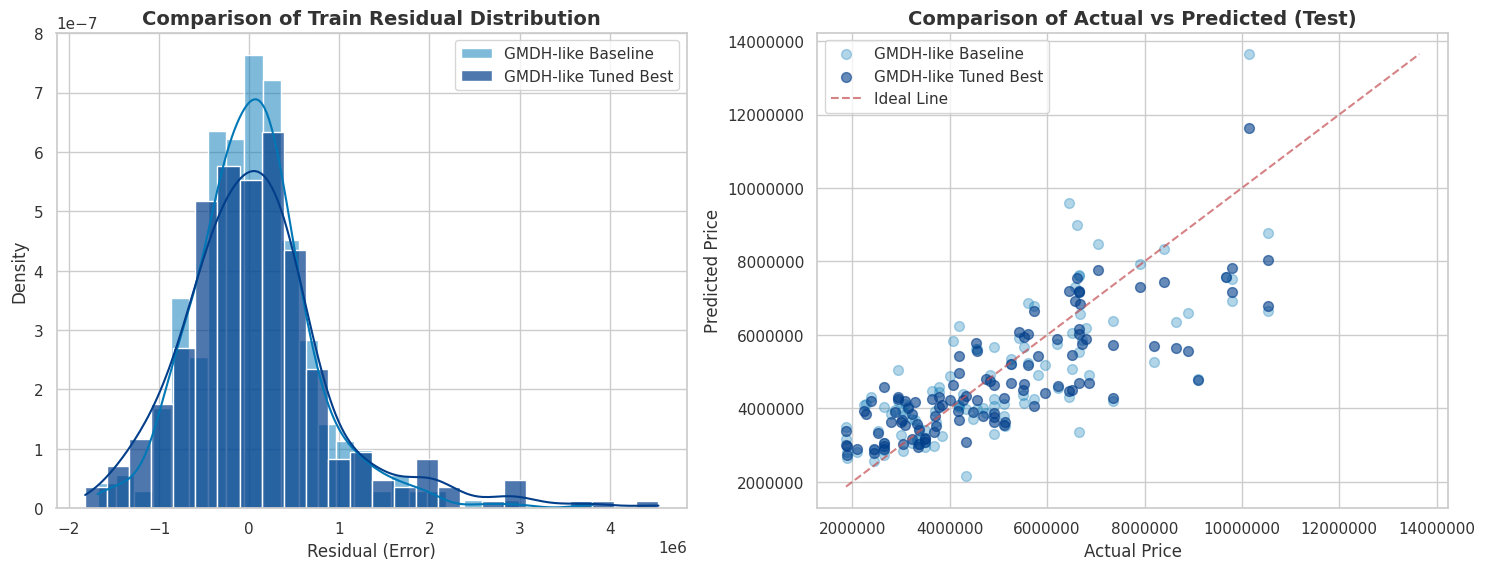

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== GMDH-like Model Comparison Visualization ===")

# --- 1. Get necessary data for GMDH-like Baseline ---
# Transform features using baseline poly object
Xtr_g_base  = poly_g_base.transform(Xtr_s)
Xte_g_base  = poly_g_base.transform(Xte_s)

# Predict on log scale, then transform back to original price scale
y_train_true_base = np.exp(y_train.values)
y_test_true_base  = np.exp(y_test.values)

y_train_pred_base = np.exp(gmdh_base_model.predict(Xtr_g_base).ravel())
y_test_pred_base  = np.exp(gmdh_base_model.predict(Xte_g_base).ravel())

# Calculate Train Residuals
train_resid_base = y_train_true_base - y_train_pred_base

# --- 2. Get necessary data for GMDH-like Tuned Best ---
# Transform features using tuned poly object
Xtr_g_tuned  = poly_g_manual_tuned.transform(Xtr_s)
Xte_g_tuned  = poly_g_manual_tuned.transform(Xte_s)

# Predict on log scale, then transform back to original price scale
y_train_true_tuned = np.exp(y_train.values) # Same as base
y_test_true_tuned  = np.exp(y_test.values)  # Same as base

y_train_pred_tuned = np.exp(gmdh_manual_tuned_model.predict(Xtr_g_tuned).ravel())
y_test_pred_tuned  = np.exp(gmdh_manual_tuned_model.predict(Xte_g_tuned).ravel())

# Calculate Train Residuals
train_resid_tuned = y_train_true_tuned - y_train_pred_tuned

# --- 3. Create comparison plots ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Compare Histograms of Train Residuals
sns.histplot(train_resid_base, kde=True, ax=axes[0], color='#0077B6', label='GMDH-like Baseline', alpha=0.5, stat='density')
sns.histplot(train_resid_tuned, kde=True, ax=axes[0], color='#023E8A', label='GMDH-like Tuned Best', alpha=0.7, stat='density')
axes[0].set_title('Comparison of Train Residual Distribution')
axes[0].set_xlabel('Residual (Error)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot 2: Compare Scatter Plot Actual vs Predicted (Test)
axes[1].scatter(y_test_true_base, y_test_pred_base, alpha=0.3, color='#0077B6', label='GMDH-like Baseline', s=50)
axes[1].scatter(y_test_true_tuned, y_test_pred_tuned, alpha=0.6, color='#023E8A', label='GMDH-like Tuned Best', s=50)

# Draw y=x line
min_val = min(y_test_true_base.min(), y_test_pred_base.min(), y_test_true_tuned.min(), y_test_pred_tuned.min())
max_val = max(y_test_true_base.max(), y_test_pred_base.max(), y_test_true_tuned.max(), y_test_pred_tuned.max())
lims = [min_val, max_val]
axes[1].plot(lims, lims, 'r--', alpha=0.7, label='Ideal Line')

axes[1].set_title('Comparison of Actual vs Predicted (Test)')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].legend()
axes[1].ticklabel_format(style='plain', axis='x')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# 16.  Comparing the Evaluation Metics of the Models

## Comparing the Evaluation Metics of the Models (OLS, XGBoost, GMDH-like)
```python
# Define the models to be included in the final comparison
chosen_models = ['OLS', 'XGBoost', 'GMDH']
# Filter df_metrics to include only the chosen best models
df_best_models_metrics = df_metrics[df_metrics['Model'].isin(chosen_models)].copy()
# 1. Display Full Metrics Table for Best Models
print("=== FULL METRICS TABLE FOR BEST MODELS (OLS, XGBoost, GMDH-like) ===")
display(df_best_models_metrics)
# 2. Display Model Ranking by Test RMSE
df_best_test_ranking = df_best_models_metrics[df_best_models_metrics["Split"] == "Test"].copy()
df_best_test_ranking = df_best_test_ranking.sort_values("RMSE").reset_index(drop=True)
print("\n=== MODEL RANKING (BY TEST RMSE – thấp hơn là tốt hơn) FOR BEST MODELS ===")
display(df_best_test_ranking)
# 3. Display Generalization Gap Analysis for Best Models
df_best_train = df_best_models_metrics[df_best_models_metrics["Split"]=="Train"].set_index("Model")
df_best_test_idx = df_best_models_metrics[df_best_models_metrics["Split"]=="Test"].set_index("Model")
df_best_gap = pd.DataFrame({
    "RMSE_train": df_best_train["RMSE"],
    "RMSE_test":  df_best_test_idx["RMSE"],
    "RMSE_diff":  df_best_test_idx["RMSE"] - df_best_train["RMSE"],
    "R2_train":   df_best_train["R2"],
    "R2_test":    df_best_test_idx["R2"],
    "R2_diff":    df_best_train["R2"] - df_best_test_idx["R2"]
})
print("\n=== GENERALIZATION GAP (TRAIN vs TEST) FOR BEST MODELS ===")
display(df_best_gap)
# 4. Visualize Test RMSE Comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=df_best_test_ranking, x="Model", y="RMSE")
plt.title("Test RMSE Comparison Across Best Models (OLS, XGBoost, GMDH-like)")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 5. Visualize Test R² Comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=df_best_test_ranking, x="Model", y="R2")
plt.title("Test R² Comparison Across Best Models (OLS, XGBoost, GMDH-like)")
plt.ylabel("R²")
plt.xlabel("Model")
plt.ylim(0, 1) # R2 typically ranges from 0 to 1 for good models
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 6. Visualize Train vs Test RMSE
df_best_rmse = df_best_gap[["RMSE_train","RMSE_test"]].reset_index()
df_best_rmse_melt = df_best_rmse.melt(
    id_vars="Model",
    value_vars=["RMSE_train","RMSE_test"],
    var_name="Split",
    value_name="RMSE"
)
df_best_rmse_melt['Split'] = df_best_rmse_melt['Split'].replace({'RMSE_train': 'Train RMSE', 'RMSE_test': 'Test RMSE'}) # Improve labels
plt.figure(figsize=(8, 5))
sns.barplot(data=df_best_rmse_melt, x="Model", y="RMSE", hue="Split")
plt.title("Train vs Test RMSE by Best Model")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 7. Visualize Train vs Test R²
df_best_r2 = df_best_gap[["R2_train","R2_test"]].reset_index()
df_best_r2_melt = df_best_r2.melt(
    id_vars="Model",
    value_vars=["R2_train","R2_test"],
    var_name="Split",
    value_name="R2"
)
df_best_r2_melt['Split'] = df_best_r2_melt['Split'].replace({'R2_train': 'Train R²', 'R2_test': 'Test R²'}) # Improve labels
plt.figure(figsize=(8, 5))
sns.barplot(data=df_best_r2_melt, x="Model", y="R2", hue="Split")
plt.title("Train vs Test R² by Best Model")
plt.ylabel("R²")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
print("=== Full Metrics Table for Best Models (OLS, XGBoost, GMDH-like) ===")
display(df_best_models_metrics)

=== Full Metrics Table for Best Models (OLS, XGBoost, GMDH-like) ===


,Model,Split,RMSE,MAE,MAPE,R2
0,OLS,Train,9.308113e+05,657666.075627,14.459295,0.707084
1,OLS,Val,9.825708e+05,738291.910182,15.288038,0.659516
2,OLS,Test,1.200600e+06,931822.196594,20.027020,0.679095
12,XGBoost,Train,7.839473e+05,550387.690951,12.172478,0.792225
13,XGBoost,Val,1.014543e+06,774672.583984,16.101511,0.636998
14,XGBoost,Test,1.163692e+06,888072.930465,19.300390,0.698521
18,GMDH,Train,8.775716e+05,612177.764940,13.442188,0.739633
19,GMDH,Val,1.009727e+06,744447.466962,15.183333,0.640436
20,GMDH,Test,1.282316e+06,977545.956517,20.999222,0.633924


In [ ]:
df_best_test_ranking = df_best_models_metrics[df_best_models_metrics["Split"] == "Test"].copy()
df_best_test_ranking = df_best_test_ranking.sort_values("RMSE").reset_index(drop=True)
print("\n=== MODEL RANKING (BY TEST RMSE – thấp hơn là tốt hơn) FOR BEST MODELS ===")
display(df_best_test_ranking)


=== MODEL RANKING (BY TEST RMSE – thấp hơn là tốt hơn) FOR BEST MODELS ===


,Model,Split,RMSE,MAE,MAPE,R2
0,XGBoost,Test,1.163692e+06,888072.930465,19.300390,0.698521
1,OLS,Test,1.200600e+06,931822.196594,20.027020,0.679095
2,GMDH,Test,1.282316e+06,977545.956517,20.999222,0.633924


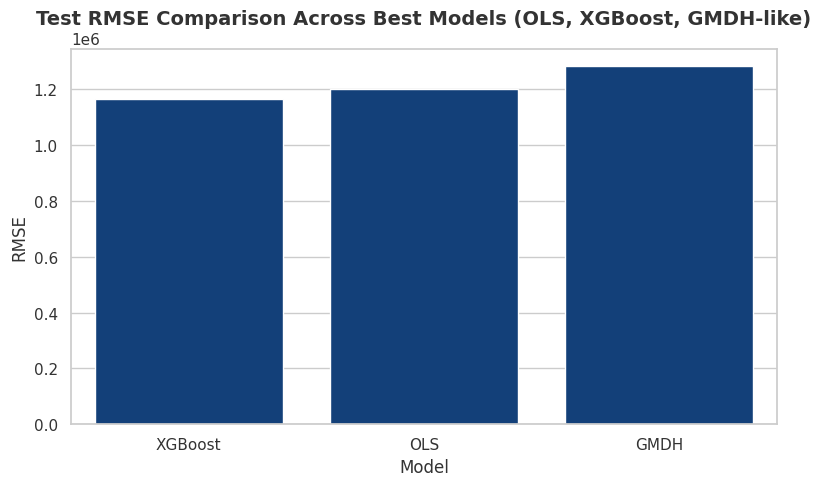

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_best_test_ranking, x="Model", y="RMSE")
plt.title("Test RMSE Comparison Across Best Models (OLS, XGBoost, GMDH-like)")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

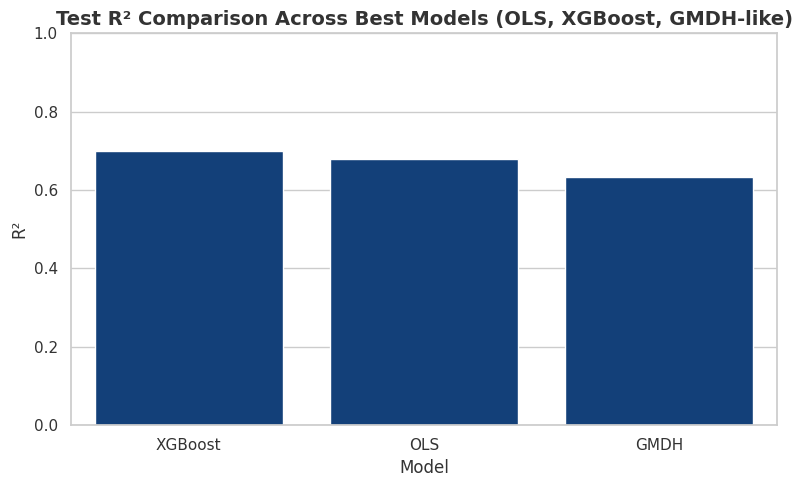

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_best_test_ranking, x="Model", y="R2")
plt.title("Test R² Comparison Across Best Models (OLS, XGBoost, GMDH-like)")
plt.ylabel("R²")
plt.xlabel("Model")
plt.ylim(0, 1) # R2 typically ranges from 0 to 1 for good models
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

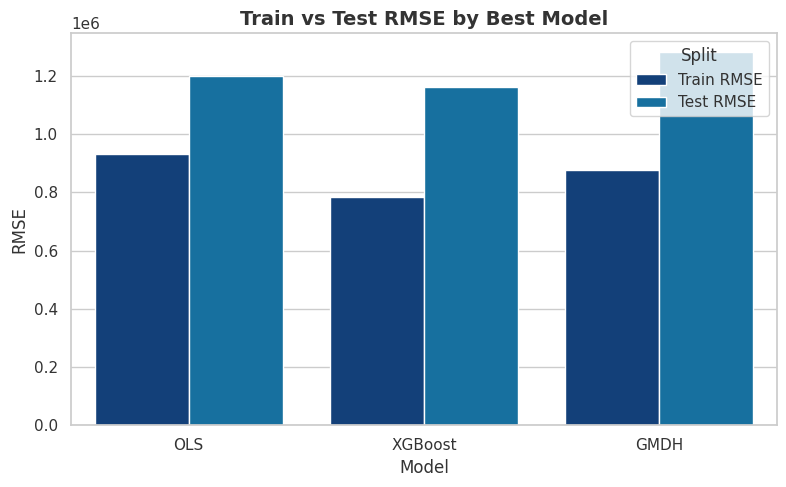

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_best_rmse_melt, x="Model", y="RMSE", hue="Split")
plt.title("Train vs Test RMSE by Best Model")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

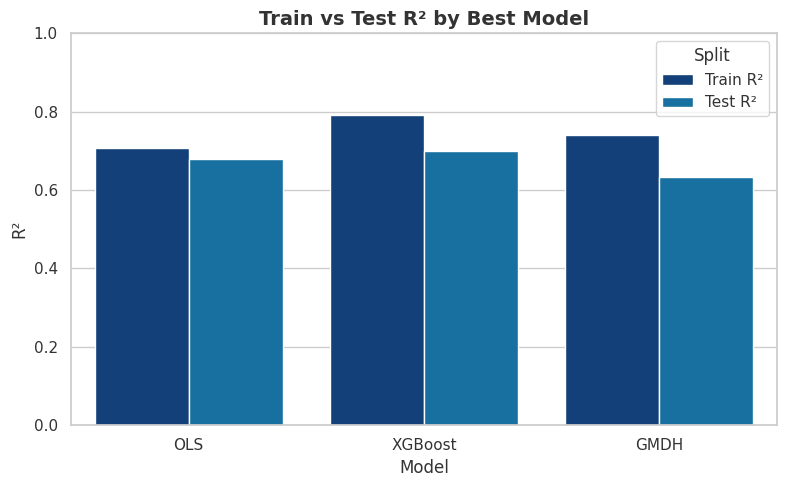

In [ ]:
df_best_r2 = df_best_gap[["R2_train","R2_test"]].reset_index()
df_best_r2_melt = df_best_r2.melt(
    id_vars="Model",
    value_vars=["R2_train","R2_test"],
    var_name="Split",
    value_name="R2"
)
df_best_r2_melt['Split'] = df_best_r2_melt['Split'].replace({'R2_train': 'Train R²', 'R2_test': 'Test R²'}) # Improve labels

plt.figure(figsize=(8, 5))
sns.barplot(data=df_best_r2_melt, x="Model", y="R2", hue="Split")
plt.title("Train vs Test R² by Best Model")
plt.ylabel("R²")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()